In [ ]:
NOM:MRIKI

PRENOM:SAAD

FILIERE:G.INFO








### Étape 1 — Chargement des données

Le fichier `.xls` (format Excel ancien) se lit avec l'engine `xlrd`.

In [10]:
# Chargement du fichier Excel (format .xls legacy → engine xlrd obligatoire)
DF_cars = pd.read_excel('cars.xls', engine='xlrd')

print(f'Dimensions du dataset : {DF_cars.shape[0]} observations × {DF_cars.shape[1]} variables')
print(f'Variables : {list(DF_cars.columns)}')
print()
DF_cars.head(10)

Dimensions du dataset : 38 observations × 8 variables
Variables : ['Country', 'Car', 'MPG', 'Weight', 'Drive_Ratio', 'Horsepower', 'Displacement', 'Cylinders']



,Country,Car,MPG,Weight,Drive_Ratio,Horsepower,Displacement,Cylinders
0,U.S.,Buick Estate Wagon,16.9,4.360,2.73,155,350,8
1,U.S.,Ford Country Squire Wagon,15.5,4.054,2.26,142,351,8
2,U.S.,Chevy Malibu Wagon,19.2,3.605,2.56,125,267,8
3,U.S.,Chrysler LeBaron Wagon,18.5,3.940,2.45,150,360,8
4,U.S.,Chevette,30.0,2.155,3.70,68,98,4
5,Japan,Toyota Corona,27.5,2.560,3.05,95,134,4
6,Japan,Datsun 510,27.2,2.300,3.54,97,119,4
7,U.S.,Dodge Omni,30.9,2.230,3.37,75,105,4
8,Germany,Audi 5000,20.3,2.830,3.90,103,131,5
9,Sweden,Volvo 240 GL,17.0,3.140,3.50,125,163,6


### Étape 2 — Résumé statistique

`describe(include='all')` affiche les statistiques pour **toutes les variables** (quantitatives ET qualitatives).

In [ ]:
# Résumé statistique complet
DF_cars.describe(include='all')

In [11]:
# Vérification des types de variables et des valeurs manquantes
print('=== Types de variables ===')
print(DF_cars.dtypes)
print()
print('=== Valeurs manquantes ===')
print(DF_cars.isnull().sum())
print()
print('=== Répartition par pays ===')
print(DF_cars['Country'].value_counts())

=== Types de variables ===
Country          object
Car              object
MPG             float64
Weight          float64
Drive_Ratio     float64
Horsepower        int64
Displacement      int64
Cylinders         int64
dtype: object

=== Valeurs manquantes ===
Country         0
Car             0
MPG             0
Weight          0
Drive_Ratio     0
Horsepower      0
Displacement    0
Cylinders       0
dtype: int64

=== Répartition par pays ===
Country
U.S.       22
Japan       7
Germany     5
Sweden      2
France      1
Italy       1
Name: count, dtype: int64


> **Interprétation :** Le dataset contient 2 variables qualitatives (`Country`, `Car`) et 6 variables quantitatives (`MPG`, `Weight`, `Drive_Ratio`, `Horsepower`, `Displacement`, `Cylinders`). Pas de valeurs manquantes.

### Étape 3 — Matrice de dispersion (Pairs plot)

Le `pairplot` permet de visualiser les relations deux-à-deux entre toutes les variables quantitatives.

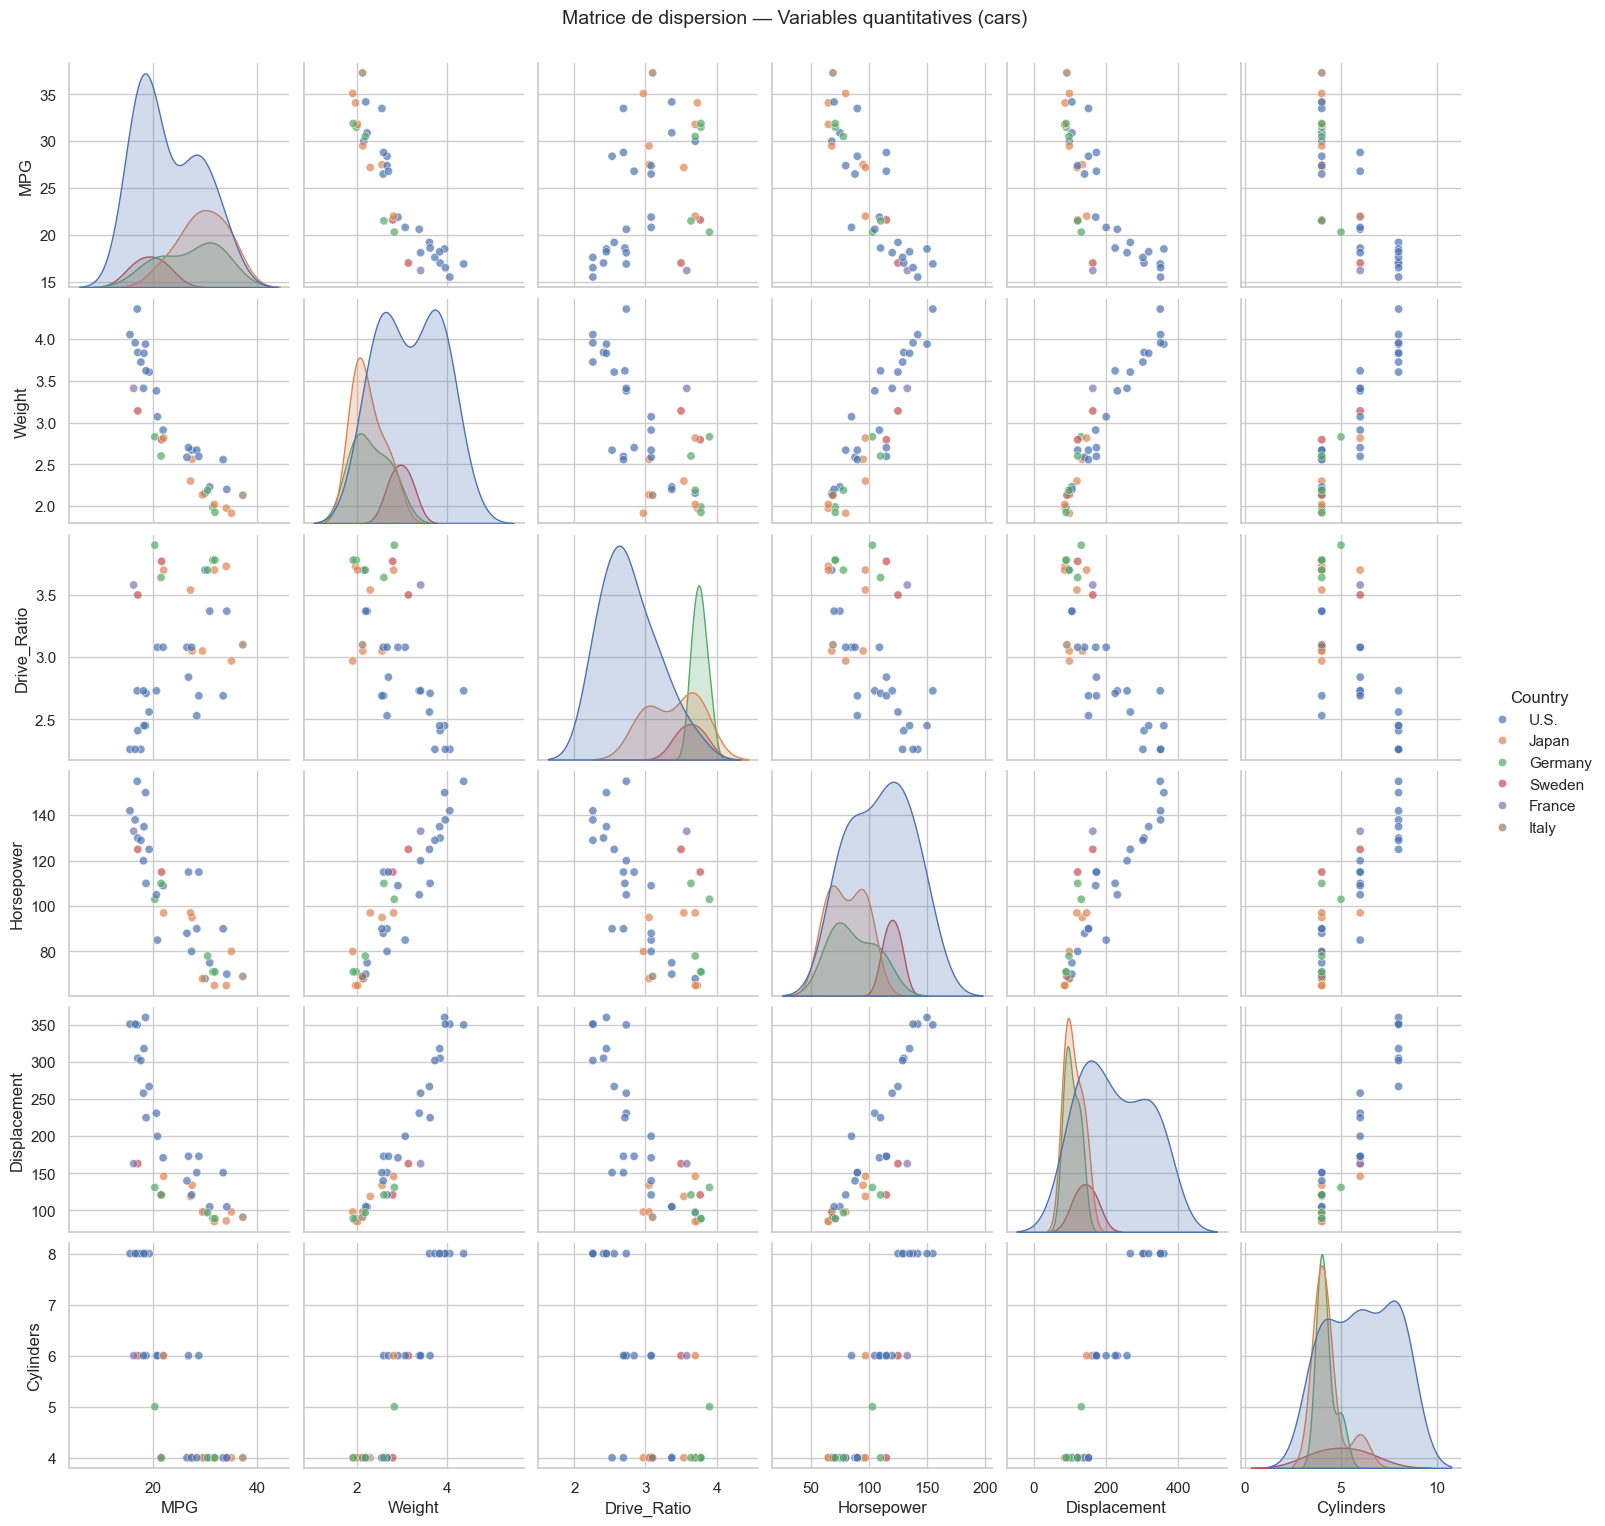

In [12]:
# On sélectionne uniquement les colonnes numériques pour le pairplot
vars_quant = ['MPG', 'Weight', 'Drive_Ratio', 'Horsepower', 'Displacement', 'Cylinders']

sns.pairplot(
    DF_cars[vars_quant + ['Country']],
    hue='Country',          # Colorier par pays d'origine
    diag_kind='kde',        # Densité sur la diagonale
    plot_kws={'alpha': 0.7}
)
plt.suptitle('Matrice de dispersion — Variables quantitatives (cars)', y=1.02, fontsize=14)
plt.show()

> **Interprétation :** On observe de fortes corrélations entre `Displacement`, `Weight`, `Horsepower`, et `Cylinders`. La variable `MPG` (consommation) est inversement corrélée à ces variables, ce qui est logique : les voitures lourdes et puissantes consomment plus.

### Étape 4 — Distance de Gower

La **distance de Gower** est adaptée aux données **mixtes** (quantitatives + qualitatives). Elle normalise chaque variable et calcule une distance globale entre [0, 1].

Shape de la matrice de Gower : (38, 38)
Valeurs min / max : 0.0000 / 0.9170



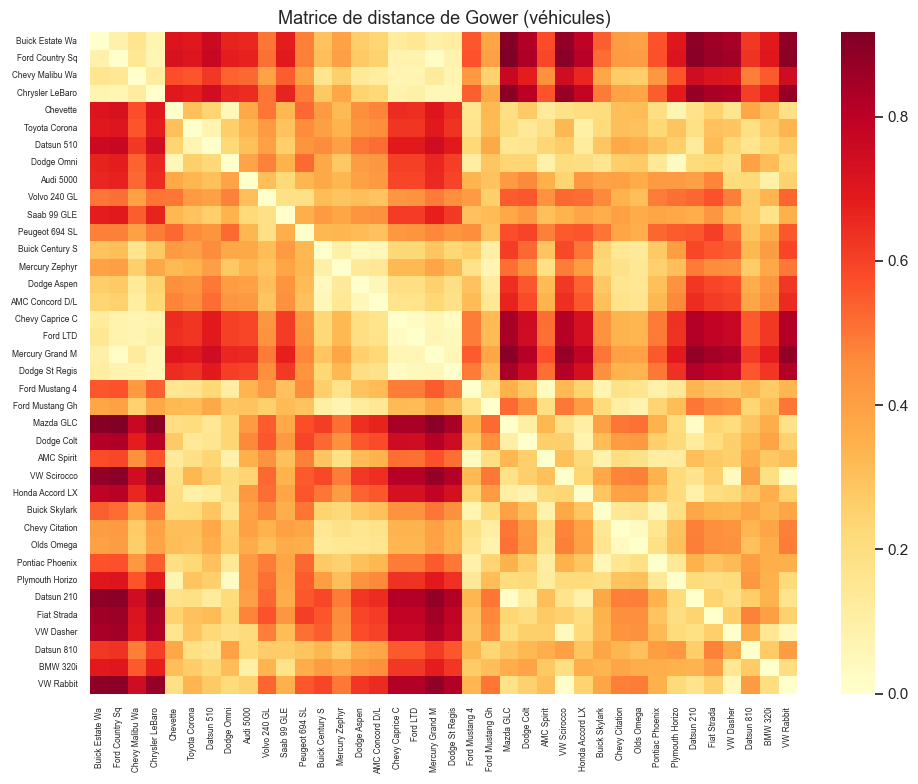

In [13]:
# Calcul de la matrice de distance de Gower (données mixtes)
# On inclut toutes les colonnes (Country étant qualitative, Gower la gère automatiquement)
DF_gower = DF_cars.drop(columns=['Car'])  # 'Car' = identifiant, on le retire

dis_cars = gower.gower_matrix(DF_gower)

print(f'Shape de la matrice de Gower : {dis_cars.shape}')  # Doit être (38, 38)
print(f'Valeurs min / max : {dis_cars.min():.4f} / {dis_cars.max():.4f}')
print()

# Visualisation de la matrice de distances
plt.figure(figsize=(10, 8))
sns.heatmap(
    dis_cars,
    cmap='YlOrRd',
    xticklabels=DF_cars['Car'].str[:15],
    yticklabels=DF_cars['Car'].str[:15]
)
plt.title('Matrice de distance de Gower (véhicules)', fontsize=13)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

> **Remarque :** Le K-means standard nécessite un espace euclidien vectoriel. On utilisera donc la **standardisation des variables quantitatives** pour le K-means. La distance de Gower sera réutilisée en Q1 (PAM / k-médoïdes).

### Étape 4b — Centrage-réduction des variables quantitatives

Le **centrage-réduction** (StandardScaler) met toutes les variables à la même échelle : moyenne = 0, écart-type = 1.  
C'est indispensable pour le K-means, sinon les variables à grande amplitude dominent la distance euclidienne.

In [14]:
# Sélection des variables quantitatives uniquement
DF_quant = DF_cars.select_dtypes(include=np.number)
print(f'Variables quantitatives retenues : {list(DF_quant.columns)}')

# Centrage-réduction
scaler = StandardScaler()
cr_cars = scaler.fit_transform(DF_quant)

# Vérification : moyenne ≈ 0, std ≈ 1
print(f'\nMoyennes après standardisation (doivent être ≈ 0) :')
print(np.round(cr_cars.mean(axis=0), 4))
print(f'\nÉcarts-types après standardisation (doivent être ≈ 1) :')
print(np.round(cr_cars.std(axis=0), 4))

Variables quantitatives retenues : ['MPG', 'Weight', 'Drive_Ratio', 'Horsepower', 'Displacement', 'Cylinders']

Moyennes après standardisation (doivent être ≈ 0) :
[ 0.  0.  0. -0.  0.  0.]

Écarts-types après standardisation (doivent être ≈ 1) :
[1. 1. 1. 1. 1. 1.]


### Étape 5 — K-means avec 3 clusters

**Paramètre `n_init=5`** : l'algorithme est lancé 5 fois avec des centres initiaux différents (aléatoires). On garde la meilleure solution (inertie minimale).

In [16]:
# K-means avec k=3
np.random.seed(42)  # Reproductibilité
kmeans_3 = KMeans(n_clusters=3, n_init=5, random_state=42)
kmeans_3.fit(cr_cars)

print('=== K-means : k=3 ===')
print(f'Inertie intra-classe (WCSS) : {kmeans_3.inertia_:.4f}')
print(f'Nombre d\'itérations : {kmeans_3.n_iter_}')

=== K-means : k=3 ===
Inertie intra-classe (WCSS) : 48.0122
Nombre d'itérations : 4


### Étape 6 — Afficher les centres des clusters

Les **centres** sont les barycentres de chaque cluster dans l'espace standardisé.

In [17]:
# Centres des clusters (dans l'espace standardisé)
centres_df = pd.DataFrame(
    kmeans_3.cluster_centers_,
    columns=DF_quant.columns,
    index=[f'Cluster {i}' for i in range(3)]
)
print('=== Centres des clusters (espace standardisé) ===')
print(centres_df.round(3))

# Centres dans l'espace original (pour faciliter l'interprétation)
centres_orig = pd.DataFrame(
    scaler.inverse_transform(kmeans_3.cluster_centers_),
    columns=DF_quant.columns,
    index=[f'Cluster {i}' for i in range(3)]
)
print('\n=== Centres des clusters (espace original) ===')
print(centres_orig.round(2))

=== Centres des clusters (espace standardisé) ===
             MPG  Weight  Drive_Ratio  Horsepower  Displacement  Cylinders
Cluster 0 -0.568   0.227        0.261       0.352        -0.025      0.139
Cluster 1  0.969  -0.882        0.418      -0.923        -0.776     -0.882
Cluster 2 -1.135   1.506       -1.313       1.390         1.690      1.647

=== Centres des clusters (espace original) ===
             MPG  Weight  Drive_Ratio  Horsepower  Displacement  Cylinders
Cluster 0  21.09    3.02         3.23      110.92        175.08       5.62
Cluster 1  31.02    2.25         3.31       77.65        109.24       4.00
Cluster 2  17.42    3.91         2.42      138.00        325.50       8.00


### Étape 7 — Afficher l'assignation des véhicules aux clusters

In [18]:
# Labels (numéro de cluster) de chaque véhicule
DF_cars['Cluster_k3'] = kmeans_3.labels_

print('=== Distribution des véhicules par cluster ===')
print(pd.Series(kmeans_3.labels_).value_counts().sort_index())

print('\n=== Véhicules par cluster ===')
for c in sorted(DF_cars['Cluster_k3'].unique()):
    voitures = DF_cars[DF_cars['Cluster_k3'] == c]['Car'].tolist()
    print(f'\n--- Cluster {c} ({len(voitures)} véhicules) ---')
    for v in voitures:
        print(f'  • {v}')

=== Distribution des véhicules par cluster ===
0    13
1    17
2     8
Name: count, dtype: int64

=== Véhicules par cluster ===

--- Cluster 0 (13 véhicules) ---
  • Audi 5000
  • Volvo 240 GL
  • Saab 99 GLE
  • Peugeot 694 SL
  • Buick Century Special
  • Mercury Zephyr
  • Dodge Aspen
  • AMC Concord D/L
  • Ford Mustang Ghia
  • Chevy Citation
  • Olds Omega
  • Datsun 810
  • BMW 320i

--- Cluster 1 (17 véhicules) ---
  • Chevette
  • Toyota Corona
  • Datsun 510
  • Dodge Omni
  • Ford Mustang 4
  • Mazda GLC
  • Dodge Colt
  • AMC Spirit
  • VW Scirocco
  • Honda Accord LX
  • Buick Skylark
  • Pontiac Phoenix
  • Plymouth Horizon
  • Datsun 210
  • Fiat Strada
  • VW Dasher
  • VW Rabbit

--- Cluster 2 (8 véhicules) ---
  • Buick Estate Wagon
  • Ford Country Squire Wagon
  • Chevy Malibu Wagon
  • Chrysler LeBaron Wagon
  • Chevy Caprice Classic
  • Ford LTD
  • Mercury Grand Marquis
  • Dodge St Regis


### Étape 8 — Choix du nombre de clusters : Méthode du coude

On fait varier `k` de 1 à 10 et on trace l'**inertie intra-classe** (WCSS).  
Le "coude" dans la courbe indique le k optimal : au-delà, le gain devient marginal.

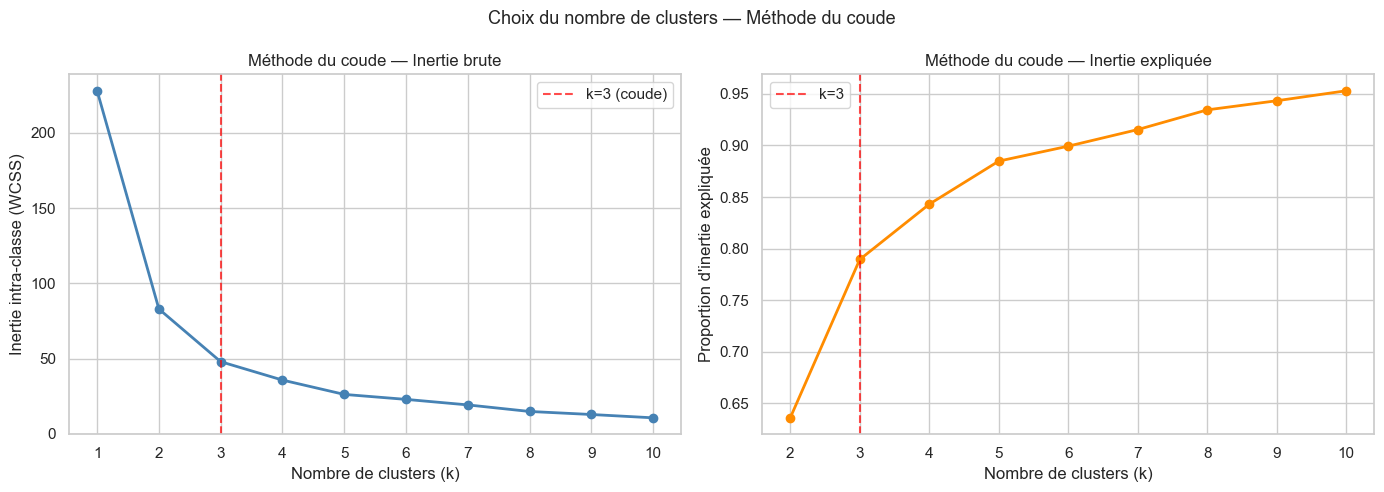


Valeurs d'inertie par k :
  k=1 → Inertie=228.00
  k=2 → Inertie=83.01
  k=3 → Inertie=48.01
  k=4 → Inertie=35.79
  k=5 → Inertie=26.27
  k=6 → Inertie=22.97
  k=7 → Inertie=19.30
  k=8 → Inertie=14.94
  k=9 → Inertie=12.93
  k=10 → Inertie=10.72


In [19]:
# Calcul de l'inertie pour k de 1 à 10
inertie_list = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=5, random_state=42)
    km.fit(cr_cars)
    inertie_list.append(km.inertia_)

# Graphe 1 : Inertie brute
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 11), inertie_list, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (coude)')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie intra-classe (WCSS)')
axes[0].set_title('Méthode du coude — Inertie brute')
axes[0].legend()
axes[0].set_xticks(range(1, 11))

# Graphe 2 : Proportion d'inertie expliquée (comme en R)
totss = inertie_list[0]  # Inertie totale (k=1)
inertie_expl = [1 - inertie_list[k-1] / totss for k in range(2, 11)]

axes[1].plot(range(2, 11), inertie_expl, marker='o', color='darkorange', linewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel("Proportion d'inertie expliquée")
axes[1].set_title("Méthode du coude — Inertie expliquée")
axes[1].legend()
axes[1].set_xticks(range(2, 11))

plt.suptitle('Choix du nombre de clusters — Méthode du coude', fontsize=13)
plt.tight_layout()
plt.show()

print('\nValeurs d\'inertie par k :')
for k, val in enumerate(inertie_list, 1):
    print(f'  k={k} → Inertie={val:.2f}')

> **Interprétation du coude :** La courbe montre une cassure significative autour de `k=3` ou `k=4`. On choisit `k=3` comme premier découpage naturel.

### Étape 9 — Segmentation finale

In [20]:
# Segmentation finale avec le k choisi par la méthode du coude
nbrClasse = 3

kmeans_final = KMeans(n_clusters=nbrClasse, n_init=5, random_state=42)
kmeans_final.fit(cr_cars)

DF_cars['Cluster_final'] = kmeans_final.labels_

print(f'✅ K-means final : k={nbrClasse}')
print(f'   Inertie : {kmeans_final.inertia_:.4f}')
print(f'   Distribution : {pd.Series(kmeans_final.labels_).value_counts().to_dict()}')

✅ K-means final : k=3
   Inertie : 48.0122
   Distribution : {1: 17, 0: 13, 2: 8}


### Étape 10 — Visualisation : Drive_Ratio vs Weight

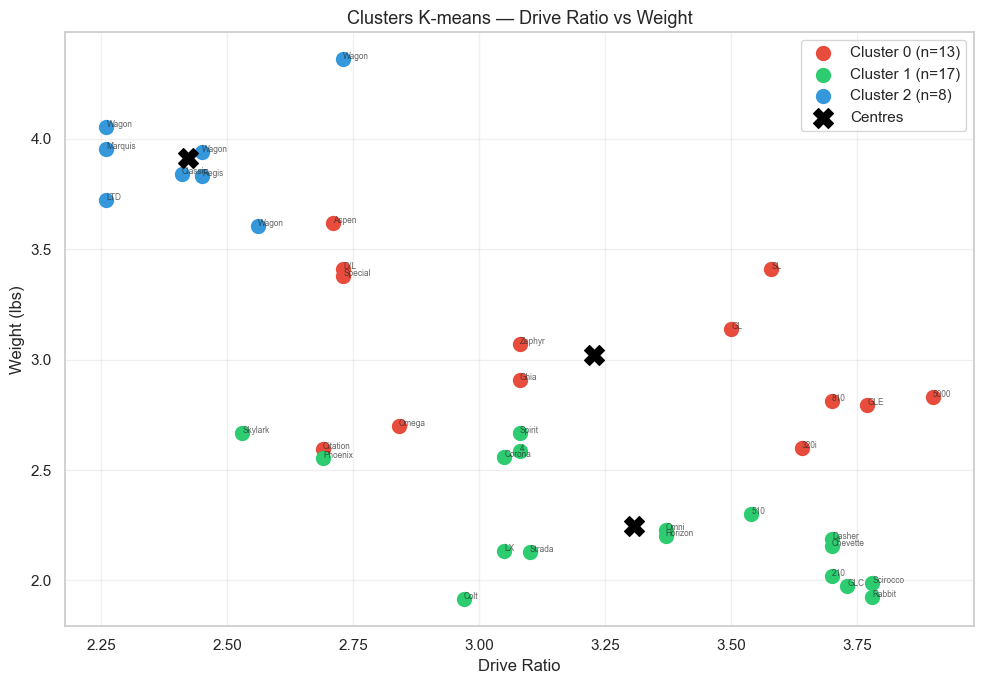

In [21]:
# Palette de couleurs distinctes pour les clusters
colors = ['#e74c3c', '#2ecc71', '#3498db']
cluster_labels = kmeans_final.labels_

fig, ax = plt.subplots(figsize=(10, 7))

for c in range(nbrClasse):
    mask = cluster_labels == c
    ax.scatter(
        DF_cars.loc[mask, 'Drive_Ratio'],
        DF_cars.loc[mask, 'Weight'],
        c=colors[c],
        s=100,
        label=f'Cluster {c} (n={mask.sum()})',
        zorder=3
    )
    # Annoter les points avec le nom du véhicule (version courte)
    for idx in DF_cars[mask].index:
        ax.annotate(
            DF_cars.loc[idx, 'Car'].split()[-1],
            (DF_cars.loc[idx, 'Drive_Ratio'], DF_cars.loc[idx, 'Weight']),
            fontsize=6, alpha=0.7
        )

# Centres des clusters (retransformés)
centres_orig2 = scaler.inverse_transform(kmeans_final.cluster_centers_)
dr_idx = list(DF_quant.columns).index('Drive_Ratio')
w_idx  = list(DF_quant.columns).index('Weight')
ax.scatter(
    centres_orig2[:, dr_idx], centres_orig2[:, w_idx],
    marker='X', s=200, c='black', zorder=5, label='Centres'
)

ax.set_xlabel('Drive Ratio', fontsize=12)
ax.set_ylabel('Weight (lbs)', fontsize=12)
ax.set_title('Clusters K-means — Drive Ratio vs Weight', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📝 Questions supplémentaires — Exercice 1

### Q1 — K-Médoïdes (PAM) avec la distance de Gower

Le **PAM (Partitioning Around Medoids)** travaille directement sur une matrice de distances (contrairement au K-means).  
Il est donc compatible avec la distance de Gower qui gère les variables mixtes.  
Les **médoïdes** sont de vrais individus (pas des barycentres), ce qui le rend plus robuste aux outliers.

In [22]:
# Implémentation manuelle du PAM (k-medoids) à partir de la matrice de Gower
# (scikit-learn-extra fournit KMedoids mais on l'implémente ici pour la clarté)

def pam_clustering(dist_matrix, k, n_init=5, random_state=42):
    """
    PAM simplifié : initialisation aléatoire + échanges itératifs.
    Retourne les labels et le coût total.
    """
    np.random.seed(random_state)
    n = dist_matrix.shape[0]
    best_labels = None
    best_cost = np.inf

    for _ in range(n_init):
        # Initialisation : choisir k médoïdes au hasard
        medoids = np.random.choice(n, k, replace=False).tolist()

        for _ in range(100):  # max 100 itérations
            # Assignation : chaque point au médoïde le plus proche
            labels = np.argmin(dist_matrix[:, medoids], axis=1)

            # Mise à jour : choisir le meilleur médoïde par cluster
            new_medoids = []
            for c in range(k):
                members = np.where(labels == c)[0]
                if len(members) == 0:
                    new_medoids.append(medoids[c])
                    continue
                sub_dist = dist_matrix[np.ix_(members, members)]
                best_local = members[np.argmin(sub_dist.sum(axis=1))]
                new_medoids.append(best_local)

            if new_medoids == medoids:
                break
            medoids = new_medoids

        # Coût = somme des distances au médoïde assigné
        cost = sum(dist_matrix[i, medoids[labels[i]]] for i in range(n))
        if cost < best_cost:
            best_cost = cost
            best_labels = labels.copy()

    return best_labels, best_cost


# Application du PAM avec k=3
labels_pam, cout_pam = pam_clustering(dis_cars, k=3)
DF_cars['Cluster_PAM'] = labels_pam

print('=== PAM (k=3) — Résultats ===')
print(f'Coût total (somme des distances Gower) : {cout_pam:.4f}')
print(f'Distribution : {pd.Series(labels_pam).value_counts().to_dict()}')

=== PAM (k=3) — Résultats ===
Coût total (somme des distances Gower) : 5.5964
Distribution : {1: 17, 2: 13, 0: 8}


=== Matrice de contingence K-means vs PAM ===
PAM      0   1   2
K-means           
0        0   0  13
1        0  17   0
2        8   0   0


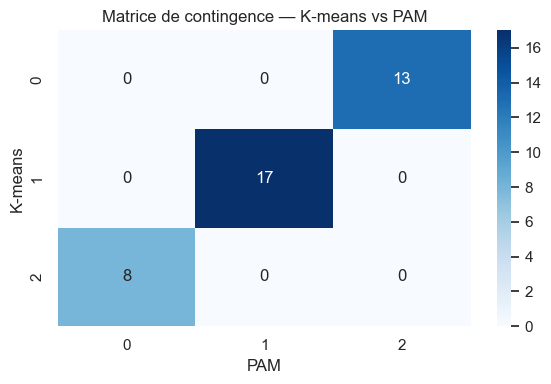


💡 Interprétation : Les cases diagonales élevées indiquent un accord entre les deux méthodes.
   Les différences viennent de la gestion des variables qualitatives (Country) dans PAM.


In [23]:
# Comparaison K-means vs PAM via une matrice de confusion
# Attention : les numéros de clusters ne sont pas alignés → on compare les structures

conf_mat = pd.crosstab(
    DF_cars['Cluster_final'],
    DF_cars['Cluster_PAM'],
    rownames=['K-means'],
    colnames=['PAM']
)

print('=== Matrice de contingence K-means vs PAM ===')
print(conf_mat)

# Visualisation
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de contingence — K-means vs PAM')
plt.tight_layout()
plt.show()

print('\n💡 Interprétation : Les cases diagonales élevées indiquent un accord entre les deux méthodes.')
print('   Les différences viennent de la gestion des variables qualitatives (Country) dans PAM.')

### Q2 — Comparaison K-means avec vs sans standardisation

In [24]:
# K-means sur données NON standardisées
km_nonscale = KMeans(n_clusters=3, n_init=5, random_state=42)
km_nonscale.fit(DF_quant.values)

# K-means sur données standardisées (déjà calculé)
km_scale = kmeans_final

DF_cars['Cluster_nonscale'] = km_nonscale.labels_

print('=== Distribution — Sans standardisation ===')
print(pd.Series(km_nonscale.labels_).value_counts().sort_index())

print('\n=== Distribution — Avec standardisation ===')
print(pd.Series(km_scale.labels_).value_counts().sort_index())

# Matrice de contingence
comp_df = pd.crosstab(
    DF_cars['Cluster_nonscale'],
    DF_cars['Cluster_final'],
    rownames=['Sans standardisation'],
    colnames=['Avec standardisation']
)
print('\n=== Matrice de contingence ===')
print(comp_df)

print('\n💡 Les clusters diffèrent car sans standardisation, Weight (en lbs) domine la distance euclidienne.')

=== Distribution — Sans standardisation ===
0    13
1     9
2    16
Name: count, dtype: int64

=== Distribution — Avec standardisation ===
0    13
1    17
2     8
Name: count, dtype: int64

=== Matrice de contingence ===
Avec standardisation   0   1  2
Sans standardisation           
0                      0  13  0
1                      1   0  8
2                     12   4  0

💡 Les clusters diffèrent car sans standardisation, Weight (en lbs) domine la distance euclidienne.


### Q3 — ACP + Visualisation des clusters

=== Variance expliquée par composante ===
  PC1 : 84.0% (cumulé : 84.0%)
  PC2 : 10.8% (cumulé : 94.8%)
  PC3 : 2.2% (cumulé : 97.0%)
  PC4 : 1.8% (cumulé : 98.9%)
  PC5 : 0.8% (cumulé : 99.7%)
  PC6 : 0.3% (cumulé : 100.0%)


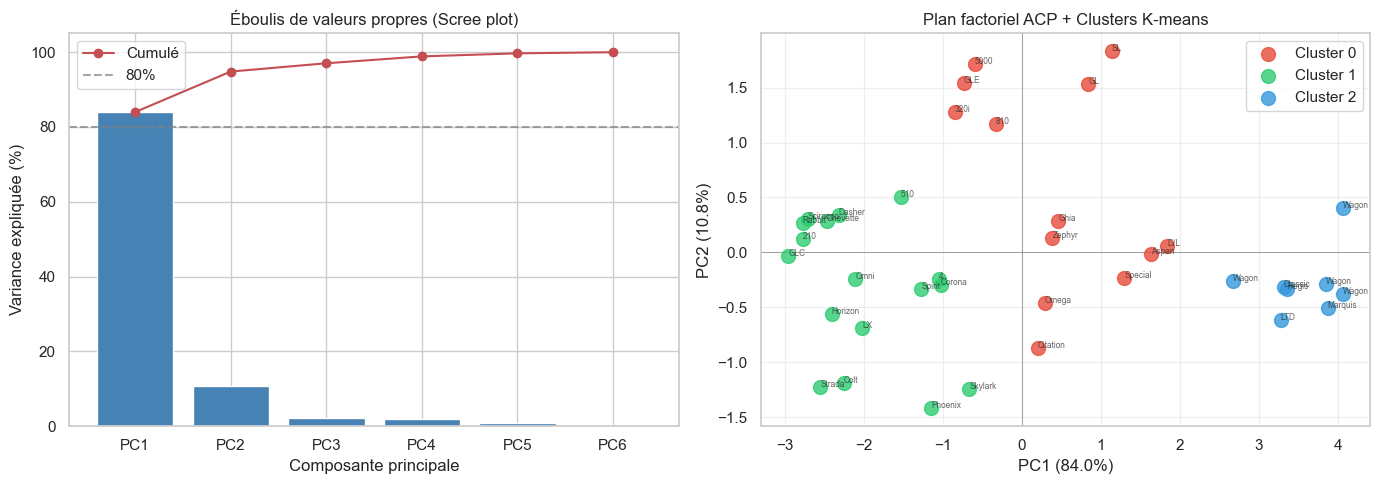

In [25]:
# ACP sur les données standardisées
pca = PCA()
coords_pca = pca.fit_transform(cr_cars)

# Variance expliquée
var_exp = pca.explained_variance_ratio_

print('=== Variance expliquée par composante ===')
for i, v in enumerate(var_exp):
    print(f'  PC{i+1} : {v*100:.1f}% (cumulé : {sum(var_exp[:i+1])*100:.1f}%)')

# Eboulis de valeurs propres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(var_exp)+1), var_exp * 100, color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(var_exp)+1), np.cumsum(var_exp) * 100, 'ro-', label='Cumulé')
axes[0].axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80%')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Éboulis de valeurs propres (Scree plot)')
axes[0].legend()
axes[0].set_xticks(range(1, len(var_exp)+1))
axes[0].set_xticklabels([f'PC{i}' for i in range(1, len(var_exp)+1)])

# Projection sur le plan factoriel (PC1 vs PC2)
colors = ['#e74c3c', '#2ecc71', '#3498db']
cluster_labels = kmeans_final.labels_

for c in range(nbrClasse):
    mask = cluster_labels == c
    axes[1].scatter(
        coords_pca[mask, 0], coords_pca[mask, 1],
        c=colors[c], s=100, label=f'Cluster {c}', alpha=0.8, zorder=3
    )
    # Labels
    for idx in np.where(mask)[0]:
        axes[1].annotate(
            DF_cars.loc[idx, 'Car'].split()[-1],
            (coords_pca[idx, 0], coords_pca[idx, 1]),
            fontsize=6, alpha=0.7
        )

axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
axes[1].set_title('Plan factoriel ACP + Clusters K-means')
axes[1].legend()
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

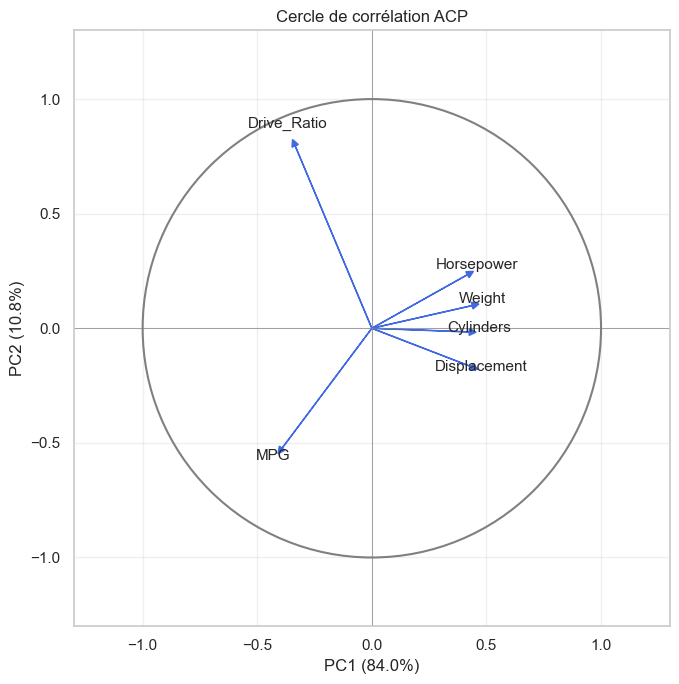

💡 Les variables proches du bord et dans la même direction sont positivement corrélées.
   MPG pointe en sens opposé à Weight/Horsepower → corrélation négative.


In [26]:
# Cercle de corrélation — variables sur le plan factoriel
loadings = pca.components_.T  # Coefficients des variables

fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linewidth=1.5)
ax.add_patch(circle)

for i, var in enumerate(DF_quant.columns):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             head_width=0.03, head_length=0.03, fc='royalblue', ec='royalblue')
    ax.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, var, fontsize=11, ha='center')

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title('Cercle de corrélation ACP')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('💡 Les variables proches du bord et dans la même direction sont positivement corrélées.')
print('   MPG pointe en sens opposé à Weight/Horsepower → corrélation négative.')

### Q4 — Effet du paramètre `n_init` sur la stabilité

In [27]:
# Test de l'effet du n_init (nombre de ré-initialisations)
results_ninit = []

for ninit in [1, 5, 20, 50]:
    inerties = []
    temps_list = []
    for _ in range(20):  # 20 répétitions pour mesurer la variabilité
        t0 = time.time()
        km = KMeans(n_clusters=3, n_init=ninit, random_state=None)  # random_state=None = aléatoire
        km.fit(cr_cars)
        t1 = time.time()
        inerties.append(km.inertia_)
        temps_list.append(t1 - t0)

    results_ninit.append({
        'n_init': ninit,
        'Inertie moyenne': np.mean(inerties),
        'Inertie std': np.std(inerties),
        'Inertie min': np.min(inerties),
        'Inertie max': np.max(inerties),
        'Temps moyen (s)': np.mean(temps_list)
    })

df_ninit = pd.DataFrame(results_ninit)
print('=== Effet du n_init sur la stabilité et l\'inertie ===')
print(df_ninit.round(4).to_string(index=False))

print('\n💡 Plus n_init est grand → inertie plus basse et plus stable, mais temps de calcul plus long.')

=== Effet du n_init sur la stabilité et l'inertie ===
 n_init  Inertie moyenne  Inertie std  Inertie min  Inertie max  Temps moyen (s)
      1          49.8286       4.1986      48.0122      67.6390           0.0056
      5          48.0122       0.0000      48.0122      48.0122           0.0182
     20          48.0122       0.0000      48.0122      48.0122           0.0762
     50          48.0122       0.0000      48.0122      48.0122           0.1814

💡 Plus n_init est grand → inertie plus basse et plus stable, mais temps de calcul plus long.


### Q5 — Indices de validation du partitionnement

- **Silhouette** ∈ [-1, 1] → plus proche de 1 = meilleur
- **Calinski-Harabasz** → plus élevé = meilleur
- **Davies-Bouldin** → plus proche de 0 = meilleur

=== Indices de validation par k ===
 k  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2      0.5168            62.8808          0.6745
 3      0.4663            65.6039          0.7996
 4      0.4713            60.8573          0.8218
 5      0.4245            63.3506          0.8920
 6      0.4322            58.9772          0.7838
 7      0.4170            55.8635          0.8014
 8      0.4517            61.6816          0.7323
 9      0.4095            62.6108          0.7775
10      0.4140            63.0753          0.7595


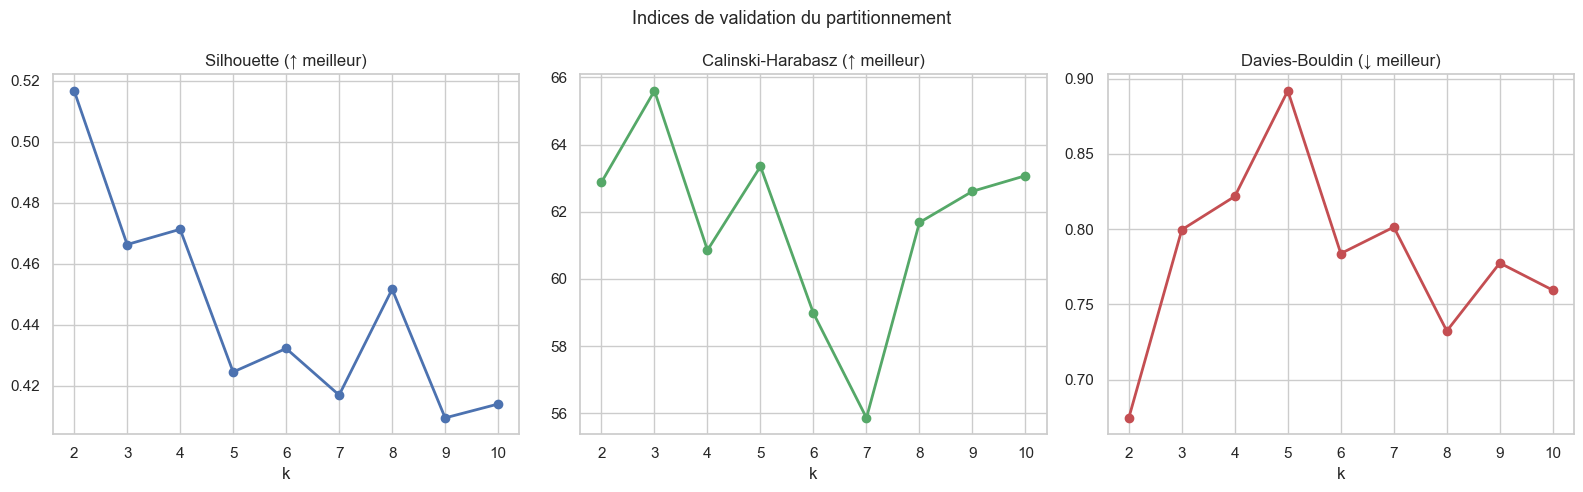


✅ Silhouette max → k optimal = 2
✅ Calinski-Harabasz max → k optimal = 3
✅ Davies-Bouldin min → k optimal = 2


In [28]:
# Calcul des indices pour k=2 à 10
indices = {'k': [], 'Silhouette': [], 'Calinski-Harabasz': [], 'Davies-Bouldin': []}

for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(cr_cars)

    indices['k'].append(k)
    indices['Silhouette'].append(silhouette_score(cr_cars, labels))
    indices['Calinski-Harabasz'].append(calinski_harabasz_score(cr_cars, labels))
    indices['Davies-Bouldin'].append(davies_bouldin_score(cr_cars, labels))

df_indices = pd.DataFrame(indices)
print('=== Indices de validation par k ===')
print(df_indices.round(4).to_string(index=False))

# Graphiques
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(df_indices['k'], df_indices['Silhouette'], 'bo-', linewidth=2)
axes[0].set_title('Silhouette (↑ meilleur)')
axes[0].set_xlabel('k'); axes[0].set_xticks(range(2, 11))

axes[1].plot(df_indices['k'], df_indices['Calinski-Harabasz'], 'go-', linewidth=2)
axes[1].set_title('Calinski-Harabasz (↑ meilleur)')
axes[1].set_xlabel('k'); axes[1].set_xticks(range(2, 11))

axes[2].plot(df_indices['k'], df_indices['Davies-Bouldin'], 'ro-', linewidth=2)
axes[2].set_title('Davies-Bouldin (↓ meilleur)')
axes[2].set_xlabel('k'); axes[2].set_xticks(range(2, 11))

plt.suptitle('Indices de validation du partitionnement', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\n✅ Silhouette max → k optimal = {df_indices.loc[df_indices["Silhouette"].idxmax(), "k"]}')
print(f'✅ Calinski-Harabasz max → k optimal = {df_indices.loc[df_indices["Calinski-Harabasz"].idxmax(), "k"]}')
print(f'✅ Davies-Bouldin min → k optimal = {df_indices.loc[df_indices["Davies-Bouldin"].idxmin(), "k"]}')

### Q6 — Distances intra-cluster et inter-cluster

In [29]:
from scipy.spatial.distance import cdist

labels_final = kmeans_final.labels_
centres_final = kmeans_final.cluster_centers_

# Distance intra-cluster = moyenne des distances de chaque point à son centre
print('=== Distances intra-cluster ===')
intra_dists = []
for c in range(nbrClasse):
    membres = cr_cars[labels_final == c]
    centre  = centres_final[c].reshape(1, -1)
    dists   = cdist(membres, centre, metric='euclidean').flatten()
    intra_dists.append(dists.mean())
    print(f'  Cluster {c} : distance intra-cluster moyenne = {dists.mean():.4f} (n={len(membres)})')

print(f'  → Moyenne globale intra-cluster : {np.mean(intra_dists):.4f}')

# Distance inter-cluster = distances entre les centres
print('\n=== Distances inter-cluster (entre centres) ===')
dist_centres = cdist(centres_final, centres_final, metric='euclidean')
df_dist = pd.DataFrame(
    dist_centres,
    index=[f'Cluster {i}' for i in range(nbrClasse)],
    columns=[f'Cluster {i}' for i in range(nbrClasse)]
)
print(df_dist.round(4))

# Ratio inter/intra : ratio élevé = bonne séparation
dist_inter_moy = dist_centres[np.triu_indices_from(dist_centres, k=1)].mean()
dist_intra_moy = np.mean(intra_dists)
print(f'\n  Ratio inter/intra = {dist_inter_moy/dist_intra_moy:.4f}')
print('  💡 Un ratio > 1 indique une bonne séparation des clusters.')

=== Distances intra-cluster ===
  Cluster 0 : distance intra-cluster moyenne = 1.3391 (n=13)
  Cluster 1 : distance intra-cluster moyenne = 1.0122 (n=17)
  Cluster 2 : distance intra-cluster moyenne = 0.6325 (n=8)
  → Moyenne globale intra-cluster : 0.9946

=== Distances inter-cluster (entre centres) ===
           Cluster 0  Cluster 1  Cluster 2
Cluster 0     0.0000     2.6169     3.2758
Cluster 1     2.6169     0.0000     5.5639
Cluster 2     3.2758     5.5639     0.0000

  Ratio inter/intra = 3.8396
  💡 Un ratio > 1 indique une bonne séparation des clusters.


### Q7 — Profils caractéristiques des clusters

=== Profils moyens par cluster (variables originales) ===
                 MPG              Weight              Drive_Ratio         \
                mean median   std   mean median   std        mean median   
Cluster_final                                                              
0              21.09   20.8  3.54   3.02   2.91  0.34        3.23   3.08   
1              31.02   30.9  3.11   2.25   2.19  0.26        3.31   3.37   
2              17.42   17.3  1.19   3.91   3.89  0.23        2.42   2.43   

                    Horsepower               Displacement                \
                std       mean median    std         mean median    std   
Cluster_final                                                             
0              0.46     110.92  110.0  12.20       175.08  171.0  42.89   
1              0.40      77.65   75.0  10.71       109.24   98.0  22.53   
2              0.17     138.00  136.5  10.50       325.50  334.0  32.82   

              Cylinders           

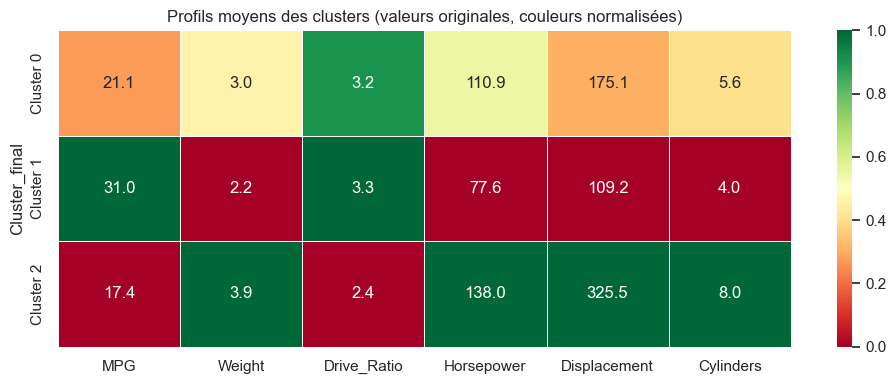


💡 Interprétation des profils :
  Cluster 0 (n=13) : MPG=21.1, HP=111, Poids=3 lbs
  Cluster 1 (n=17) : MPG=31.0, HP=78, Poids=2 lbs
  Cluster 2 (n=8) : MPG=17.4, HP=138, Poids=4 lbs


In [30]:
# Statistiques descriptives par cluster
print('=== Profils moyens par cluster (variables originales) ===')
profils = DF_cars.groupby('Cluster_final')[vars_quant].agg(['mean', 'median', 'std'])
print(profils.round(2))

# Heatmap des moyennes par cluster
moyennes = DF_cars.groupby('Cluster_final')[vars_quant].mean()

# Normalisation pour la heatmap
moyennes_norm = (moyennes - moyennes.min()) / (moyennes.max() - moyennes.min())

plt.figure(figsize=(10, 4))
sns.heatmap(
    moyennes_norm,
    annot=moyennes.round(1),  # Valeurs originales en annotation
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    yticklabels=[f'Cluster {i}' for i in moyennes.index]
)
plt.title('Profils moyens des clusters (valeurs originales, couleurs normalisées)')
plt.tight_layout()
plt.show()

print('\n💡 Interprétation des profils :')
for c in range(nbrClasse):
    n = (DF_cars['Cluster_final'] == c).sum()
    mpg = DF_cars[DF_cars['Cluster_final'] == c]['MPG'].mean()
    hp  = DF_cars[DF_cars['Cluster_final'] == c]['Horsepower'].mean()
    w   = DF_cars[DF_cars['Cluster_final'] == c]['Weight'].mean()
    print(f'  Cluster {c} (n={n}) : MPG={mpg:.1f}, HP={hp:.0f}, Poids={w:.0f} lbs')

---
# 🧀 EXERCICE 2 — CAH sur les données `fromage.txt`

**Contexte :** 29 fromages décrits par 9 propriétés nutritives.  
On utilise la **Classification Ascendante Hiérarchique (CAH)** avec la méthode de Ward.

---

### Étape 1 — Chargement des données fromage

In [31]:
# Chargement du fichier texte tabulé
fromage = pd.read_csv('fromage.txt', sep='\t', decimal='.', index_col=0)

print(f'Dimensions : {fromage.shape[0]} fromages × {fromage.shape[1]} variables')
print(f'Variables : {list(fromage.columns)}')
print()
fromage.head(10)

Dimensions : 29 fromages × 9 variables
Variables : ['calories', 'sodium', 'calcium', 'lipides', 'retinol', 'folates', 'proteines', 'cholesterol', 'magnesium']



,calories,sodium,calcium,lipides,retinol,folates,proteines,cholesterol,magnesium
Fromages,,,,,,,,,
CarredelEst,314,353.5,72.6,26.3,51.6,30.3,21.0,70,20
Babybel,314,238.0,209.8,25.1,63.7,6.4,22.6,70,27
Beaufort,401,112.0,259.4,33.3,54.9,1.2,26.6,120,41
Bleu,342,336.0,211.1,28.9,37.1,27.5,20.2,90,27
Camembert,264,314.0,215.9,19.5,103.0,36.4,23.4,60,20
Cantal,367,256.0,264.0,28.8,48.8,5.7,23.0,90,30
Chabichou,344,192.0,87.2,27.9,90.1,36.3,19.5,80,36
Chaource,292,276.0,132.9,25.4,116.4,32.5,17.8,70,25
Cheddar,406,172.0,182.3,32.5,76.4,4.9,26.0,110,28


### Étape 2 — Résumé statistique

In [32]:
print('=== Statistiques descriptives ===')
print(fromage.describe().round(2))

print('\n=== Valeurs manquantes ===')
print(fromage.isnull().sum())

=== Statistiques descriptives ===
       calories  sodium  calcium  lipides  retinol  folates  proteines  \
count     29.00   29.00    29.00    29.00    29.00    29.00      29.00   
mean     300.03  210.09   185.73    24.16    67.56    13.01      20.17   
std       91.91  108.68    72.53     8.13    24.16    11.72       6.96   
min       70.00   22.00    72.60     3.40    37.10     1.20       4.10   
25%      292.00  140.00   132.90    23.40    51.60     4.90      17.80   
50%      321.00  223.00   202.30    26.30    62.30     6.40      21.00   
75%      355.00  276.00   220.50    29.10    76.40    21.10      23.40   
max      406.00  432.00   334.60    33.30   150.50    36.40      35.70   

       cholesterol  magnesium  
count        29.00      29.00  
mean         74.59      26.97  
std          28.25      11.32  
min          10.00      10.00  
25%          70.00      20.00  
50%          80.00      26.00  
75%          90.00      30.00  
max         120.00      51.00  

=== Valeur

### Étape 3 — Graphe de corrélation

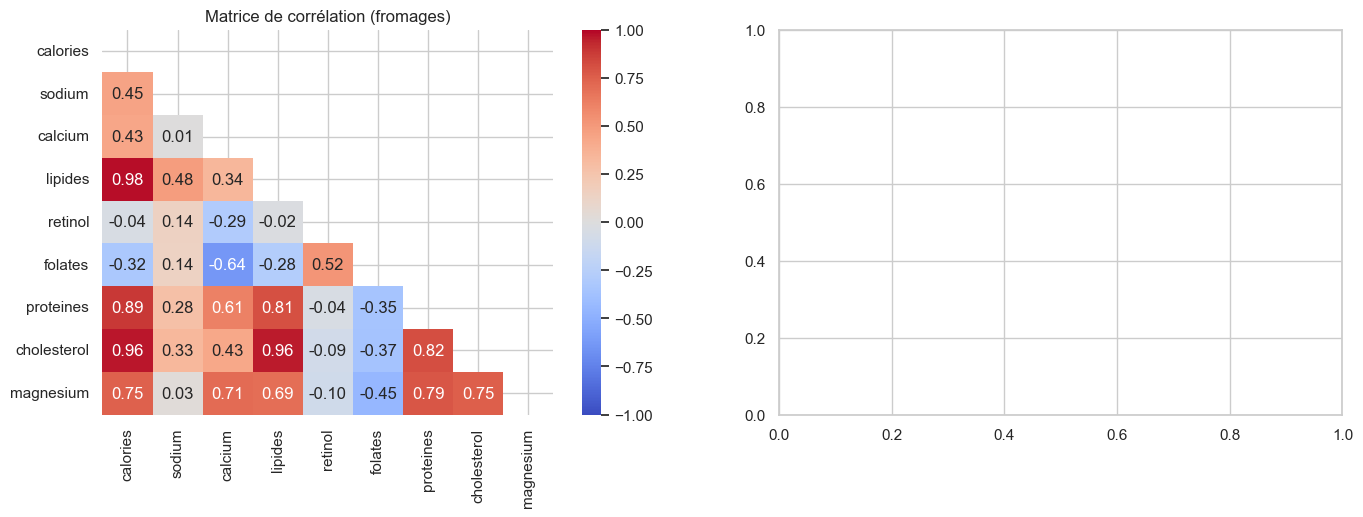

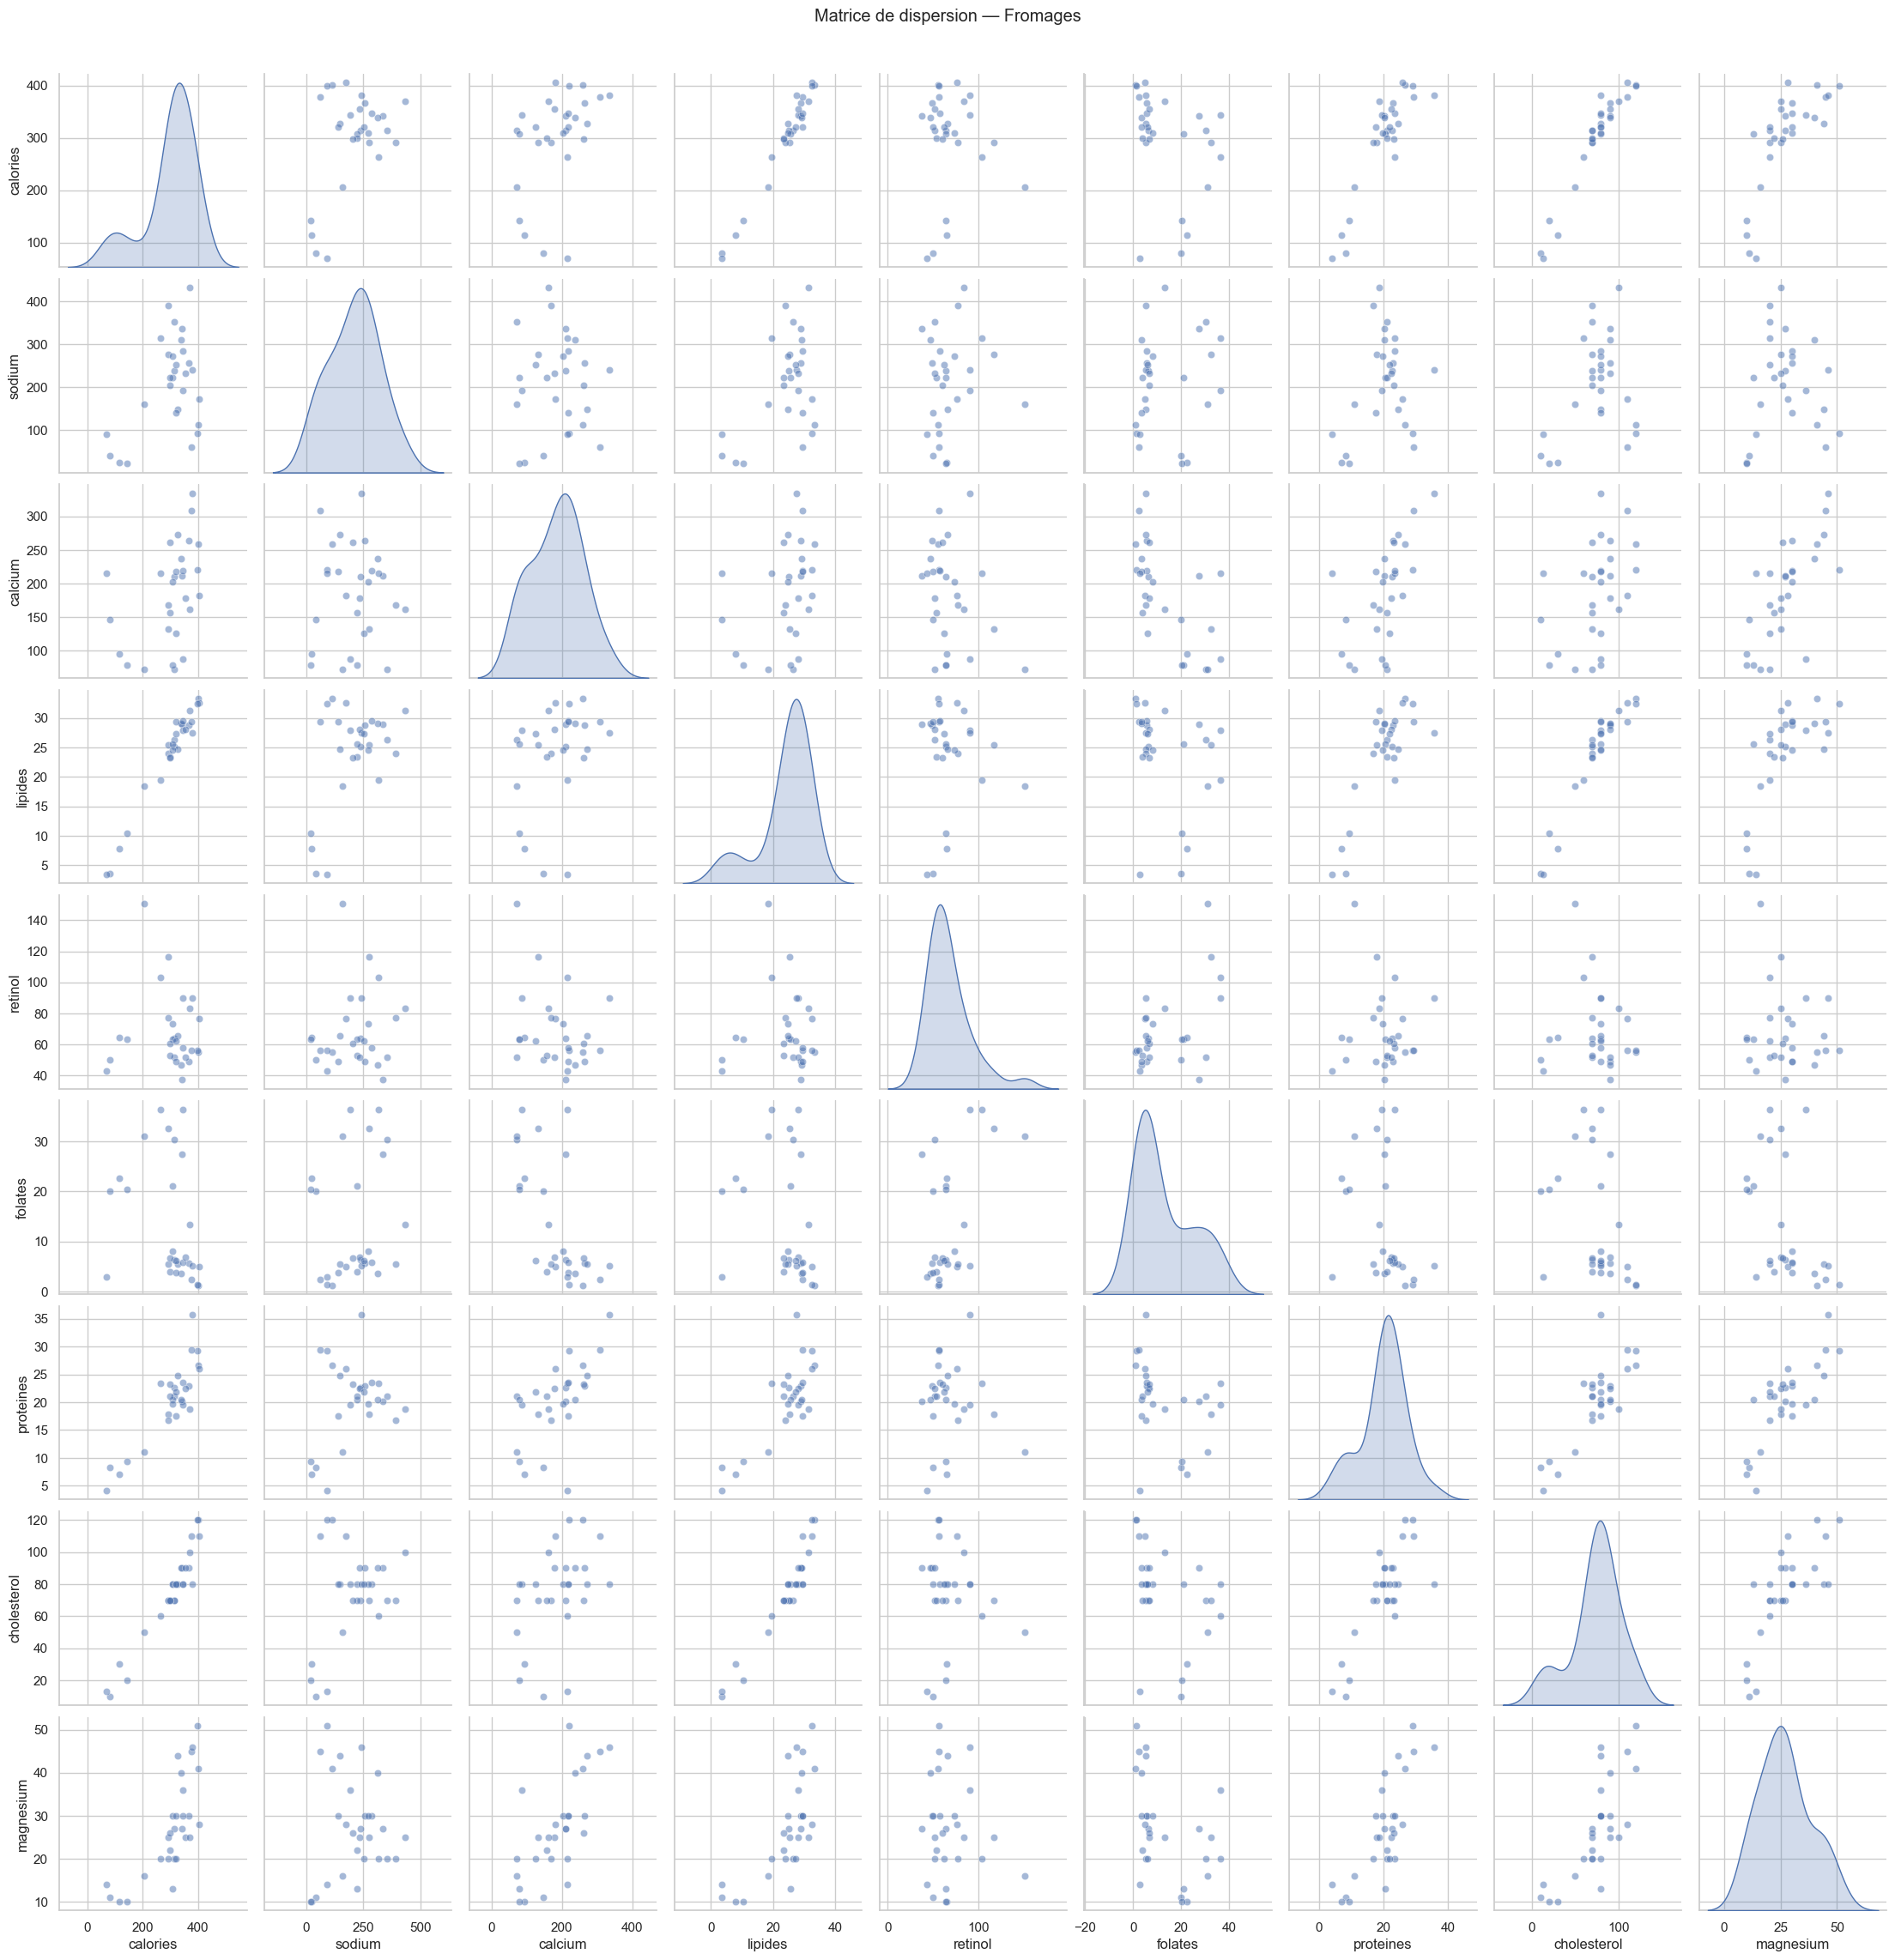

In [33]:
# Heatmap de corrélation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

corr_matrix = fromage.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, ax=axes[0], vmin=-1, vmax=1
)
axes[0].set_title('Matrice de corrélation (fromages)')

# Pairplot (diagonale = KDE)
sns.pairplot(fromage, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Matrice de dispersion — Fromages', y=1.02)
plt.show()

### Étape 4 — Centrage-réduction

In [34]:
scaler_fr = StandardScaler()
fromage_cr = scaler_fr.fit_transform(fromage)

# DataFrame avec les noms de fromages
fromage_cr_df = pd.DataFrame(fromage_cr, columns=fromage.columns, index=fromage.index)

print('✅ Données standardisées (extrait) :')
print(fromage_cr_df.round(3).head())
print(f'\nMoyenne (≈0) : {fromage_cr.mean(axis=0).round(4)}')
print(f'Std (≈1)     : {fromage_cr.std(axis=0).round(4)}')

✅ Données standardisées (extrait) :
             calories  sodium  calcium  lipides  retinol  folates  proteines  \
Fromages                                                                       
CarredelEst     0.155   1.343   -1.587    0.268   -0.672    1.501      0.122   
Babybel         0.155   0.261    0.338    0.118   -0.163   -0.574      0.355   
Beaufort        1.118  -0.919    1.034    1.144   -0.533   -1.025      0.940   
Bleu            0.465   1.179    0.356    0.594   -1.283    1.258      0.005   
Camembert      -0.399   0.973    0.423   -0.583    1.493    2.030      0.472   

             cholesterol  magnesium  
Fromages                             
CarredelEst       -0.165     -0.626  
Babybel           -0.165      0.003  
Beaufort           1.636      1.262  
Bleu               0.555      0.003  
Camembert         -0.526     -0.626  

Moyenne (≈0) : [-0.  0.  0.  0. -0.  0.  0. -0.  0.]
Std (≈1)     : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Étape 5 — Matrice de distances euclidiennes

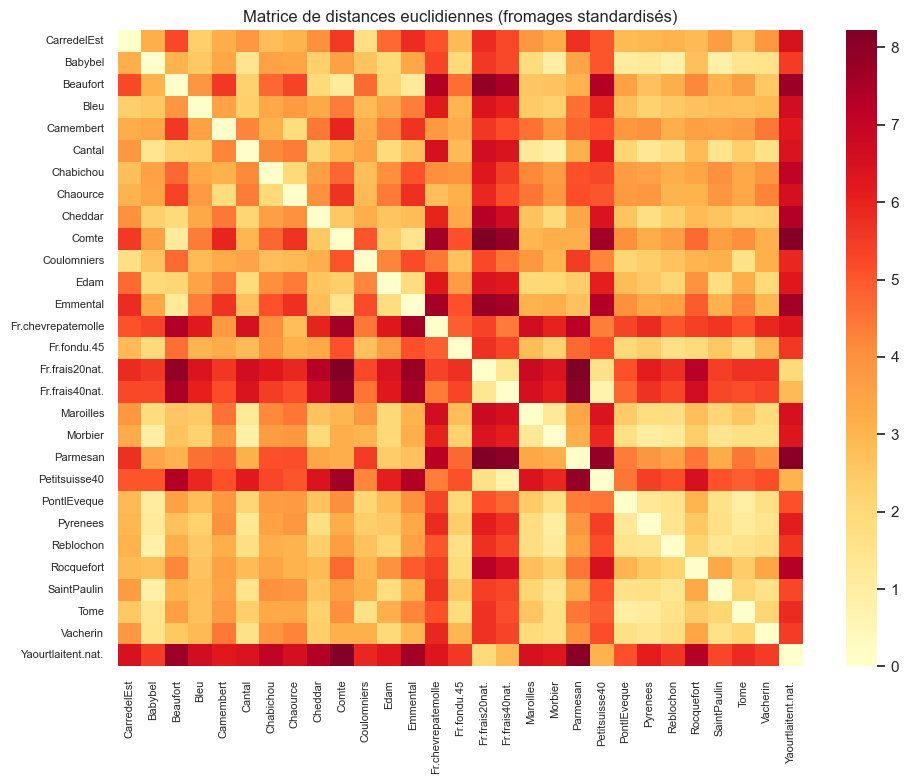

In [35]:
# pdist retourne la forme compacte (triangle supérieur)
fromage_dist = pdist(fromage_cr, metric='euclidean')

# Visualisation sous forme matricielle
dist_matrix_fr = squareform(fromage_dist)

plt.figure(figsize=(10, 8))
sns.heatmap(
    dist_matrix_fr,
    xticklabels=fromage.index,
    yticklabels=fromage.index,
    cmap='YlOrRd'
)
plt.title('Matrice de distances euclidiennes (fromages standardisés)')
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Étape 6 — CAH avec la méthode de Ward

La **méthode de Ward** minimise la variance intra-cluster à chaque fusion. Elle tend à produire des clusters bien équilibrés et compacts.

In [36]:
# Calcul de la hiérarchie avec Ward
cah_ward = linkage(fromage_dist, method='ward')

print(f'Matrice de liaison (5 premières fusions) :')
print('  [idx1, idx2, distance, n_membres]')
for row in cah_ward[:5]:
    print(f'  {row}')

Matrice de liaison (5 premières fusions) :
  [idx1, idx2, distance, n_membres]
  [16.        20.         0.7356902  2.       ]
  [ 1.         23.          0.82483528  2.        ]
  [ 5.         18.          0.89672969  2.        ]
  [21.         26.          0.95935419  2.        ]
  [2.         9.         1.14064288 2.        ]


### Étape 7 — Affichage du dendrogramme

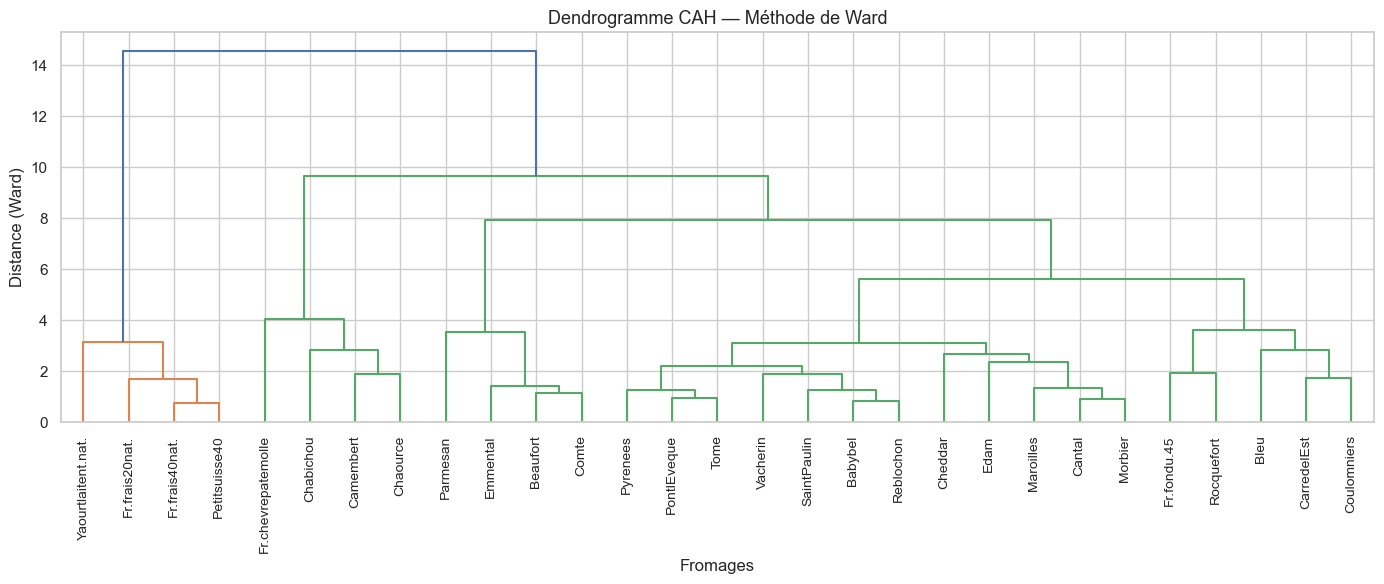

In [37]:
def plot_dendrogram(linkage_matrix, labels, title, color_threshold=None, figsize=(14, 6)):
    """Fonction utilitaire pour afficher un dendrogramme propre."""
    fig, ax = plt.subplots(figsize=figsize)
    
    dendrogram(
        linkage_matrix,
        labels=labels,
        ax=ax,
        color_threshold=color_threshold,
        leaf_rotation=90,
        leaf_font_size=10
    )
    
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Fromages')
    ax.set_ylabel('Distance (Ward)')
    
    if color_threshold:
        ax.axhline(y=color_threshold, color='red', linestyle='--', linewidth=1.5,
                   label=f'Seuil de coupure = {color_threshold:.1f}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()


# Dendrogramme Ward
plot_dendrogram(cah_ward, fromage.index, 'Dendrogramme CAH — Méthode de Ward')

### Étape 8 — Analyse des sauts d'inertie

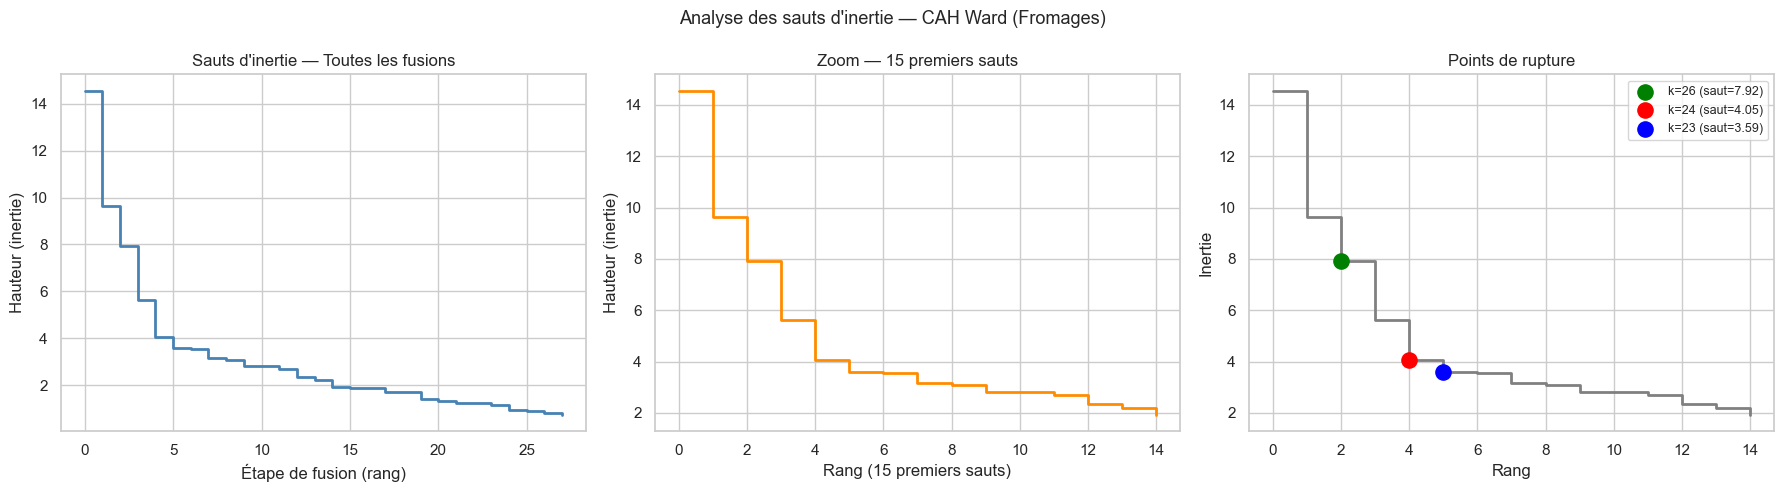

Top 10 des sauts d'inertie :
  Rang 0 → Hauteur = 14.5581 (correspond à k ≈ 28)
  Rang 1 → Hauteur = 9.6478 (correspond à k ≈ 27)
  Rang 2 → Hauteur = 7.9208 (correspond à k ≈ 26)
  Rang 3 → Hauteur = 5.6177 (correspond à k ≈ 25)
  Rang 4 → Hauteur = 4.0452 (correspond à k ≈ 24)
  Rang 5 → Hauteur = 3.5932 (correspond à k ≈ 23)
  Rang 6 → Hauteur = 3.5508 (correspond à k ≈ 22)
  Rang 7 → Hauteur = 3.1497 (correspond à k ≈ 21)
  Rang 8 → Hauteur = 3.0964 (correspond à k ≈ 20)
  Rang 9 → Hauteur = 2.8324 (correspond à k ≈ 19)


In [38]:
# a) Toutes les hauteurs (inerties) triées par ordre décroissant
inertie = np.sort(cah_ward[:, 2])[::-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphe a : Toutes les hauteurs
axes[0].plot(range(len(inertie)), inertie, drawstyle='steps-post', color='steelblue', linewidth=2)
axes[0].set_xlabel('Étape de fusion (rang)')
axes[0].set_ylabel('Hauteur (inertie)')
axes[0].set_title('Sauts d\'inertie — Toutes les fusions')

# Graphe b : Zoom sur les 15 premiers sauts
axes[1].plot(range(15), inertie[:15], drawstyle='steps-post', color='darkorange', linewidth=2)
axes[1].set_xlabel('Rang (15 premiers sauts)')
axes[1].set_ylabel('Hauteur (inertie)')
axes[1].set_title('Zoom — 15 premiers sauts')

# Graphe c : Points de rupture annotés
ruptures = [2, 4, 5]  # Indices des points de rupture
couleurs = ['green', 'red', 'blue']
axes[2].plot(range(15), inertie[:15], drawstyle='steps-post', color='gray', linewidth=2)
for idx, col in zip(ruptures, couleurs):
    axes[2].scatter(idx, inertie[idx], color=col, s=120, zorder=5,
                    label=f'k={len(inertie)-idx} (saut={inertie[idx]:.2f})')
axes[2].set_xlabel('Rang')
axes[2].set_ylabel('Inertie')
axes[2].set_title('Points de rupture')
axes[2].legend(fontsize=9)

plt.suptitle('Analyse des sauts d\'inertie — CAH Ward (Fromages)', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 10 des sauts d\'inertie :')
for i, val in enumerate(inertie[:10]):
    print(f'  Rang {i} → Hauteur = {val:.4f} (correspond à k ≈ {len(inertie)-i})')

### Étape 8d — Visualisation des partitions (découpe de l'arbre)

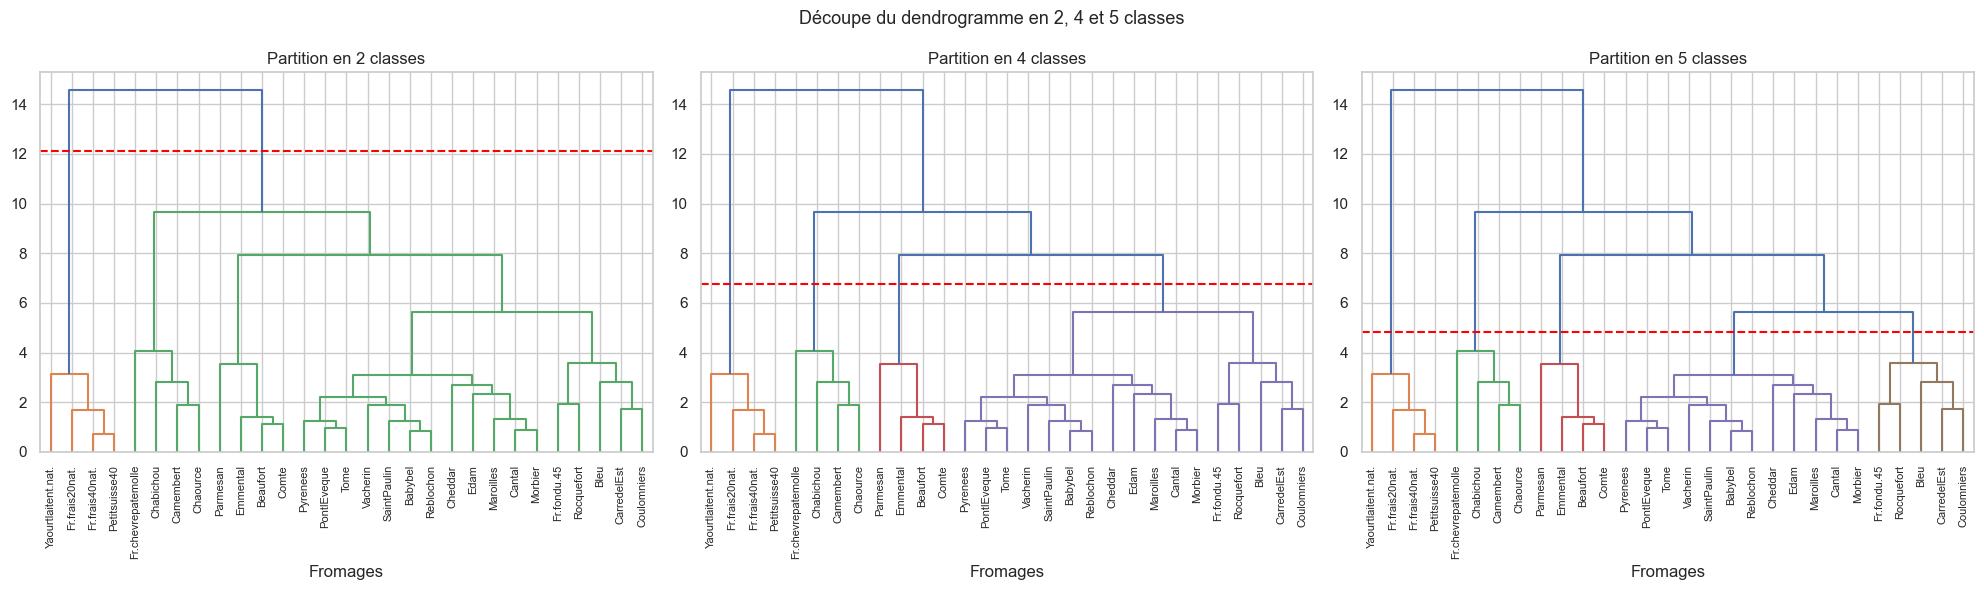

In [39]:
# Partitions en 2, 4 et 5 classes
groupes_2 = cut_tree(cah_ward, n_clusters=2).flatten()
groupes_4 = cut_tree(cah_ward, n_clusters=4).flatten()
groupes_5 = cut_tree(cah_ward, n_clusters=5).flatten()

# Seuils de coupure correspondants
# Pour k groupes, le seuil se situe entre la (n-k)ème et (n-k+1)ème fusion
n = len(fromage)
seuil_2 = (cah_ward[n-2, 2] + cah_ward[n-3, 2]) / 2
seuil_4 = (cah_ward[n-4, 2] + cah_ward[n-5, 2]) / 2
seuil_5 = (cah_ward[n-5, 2] + cah_ward[n-6, 2]) / 2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, k, groupes, seuil in [
    (axes[0], 2, groupes_2, seuil_2),
    (axes[1], 4, groupes_4, seuil_4),
    (axes[2], 5, groupes_5, seuil_5)
]:
    dendrogram(
        cah_ward, labels=fromage.index, ax=ax,
        color_threshold=seuil, leaf_rotation=90, leaf_font_size=8
    )
    ax.axhline(y=seuil, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'Partition en {k} classes')
    ax.set_xlabel('Fromages')

plt.suptitle('Découpe du dendrogramme en 2, 4 et 5 classes', fontsize=13)
plt.tight_layout()
plt.show()

### Étape 8e — Partition finale en 4 classes

In [40]:
groupes_cah = cut_tree(cah_ward, n_clusters=4).flatten()
fromage['Groupe_CAH'] = groupes_cah

print('=== Partition finale en 4 classes ===')

=== Partition finale en 4 classes ===


### Étape 9 — Lister les fromages par groupe

In [41]:
res = pd.DataFrame({'Fromage': fromage.index, 'Groupe': groupes_cah})
print(res.sort_values('Groupe').to_string(index=False))

print('\n=== Composition des groupes ===')
for g in sorted(res['Groupe'].unique()):
    membres = res[res['Groupe'] == g]['Fromage'].tolist()
    print(f'\nGroupe {g} ({len(membres)} fromages) :')
    for m in membres:
        print(f'  • {m}')

           Fromage  Groupe
       CarredelEst       0
              Tome       0
       SaintPaulin       0
        Rocquefort       0
         Reblochon       0
          Pyrenees       0
       PontlEveque       0
           Morbier       0
         Maroilles       0
          Vacherin       0
              Edam       0
       Fr.fondu.45       0
           Babybel       0
           Cheddar       0
       Coulomniers       0
            Cantal       0
              Bleu       0
          Emmental       1
             Comte       1
          Beaufort       1
          Parmesan       1
Fr.chevrepatemolle       2
          Chaource       2
         Chabichou       2
         Camembert       2
     Petitsuisse40       3
    Fr.frais20nat.       3
    Fr.frais40nat.       3
Yaourtlaitent.nat.       3

=== Composition des groupes ===

Groupe 0 (17 fromages) :
  • CarredelEst
  • Babybel
  • Bleu
  • Cantal
  • Cheddar
  • Coulomniers
  • Edam
  • Fr.fondu.45
  • Maroilles
  • Morbier
  • 

---
## 📝 Questions supplémentaires — Exercice 2

### Q1 — Comparaison des méthodes d'agrégation (Single, Complete, Average, Ward)

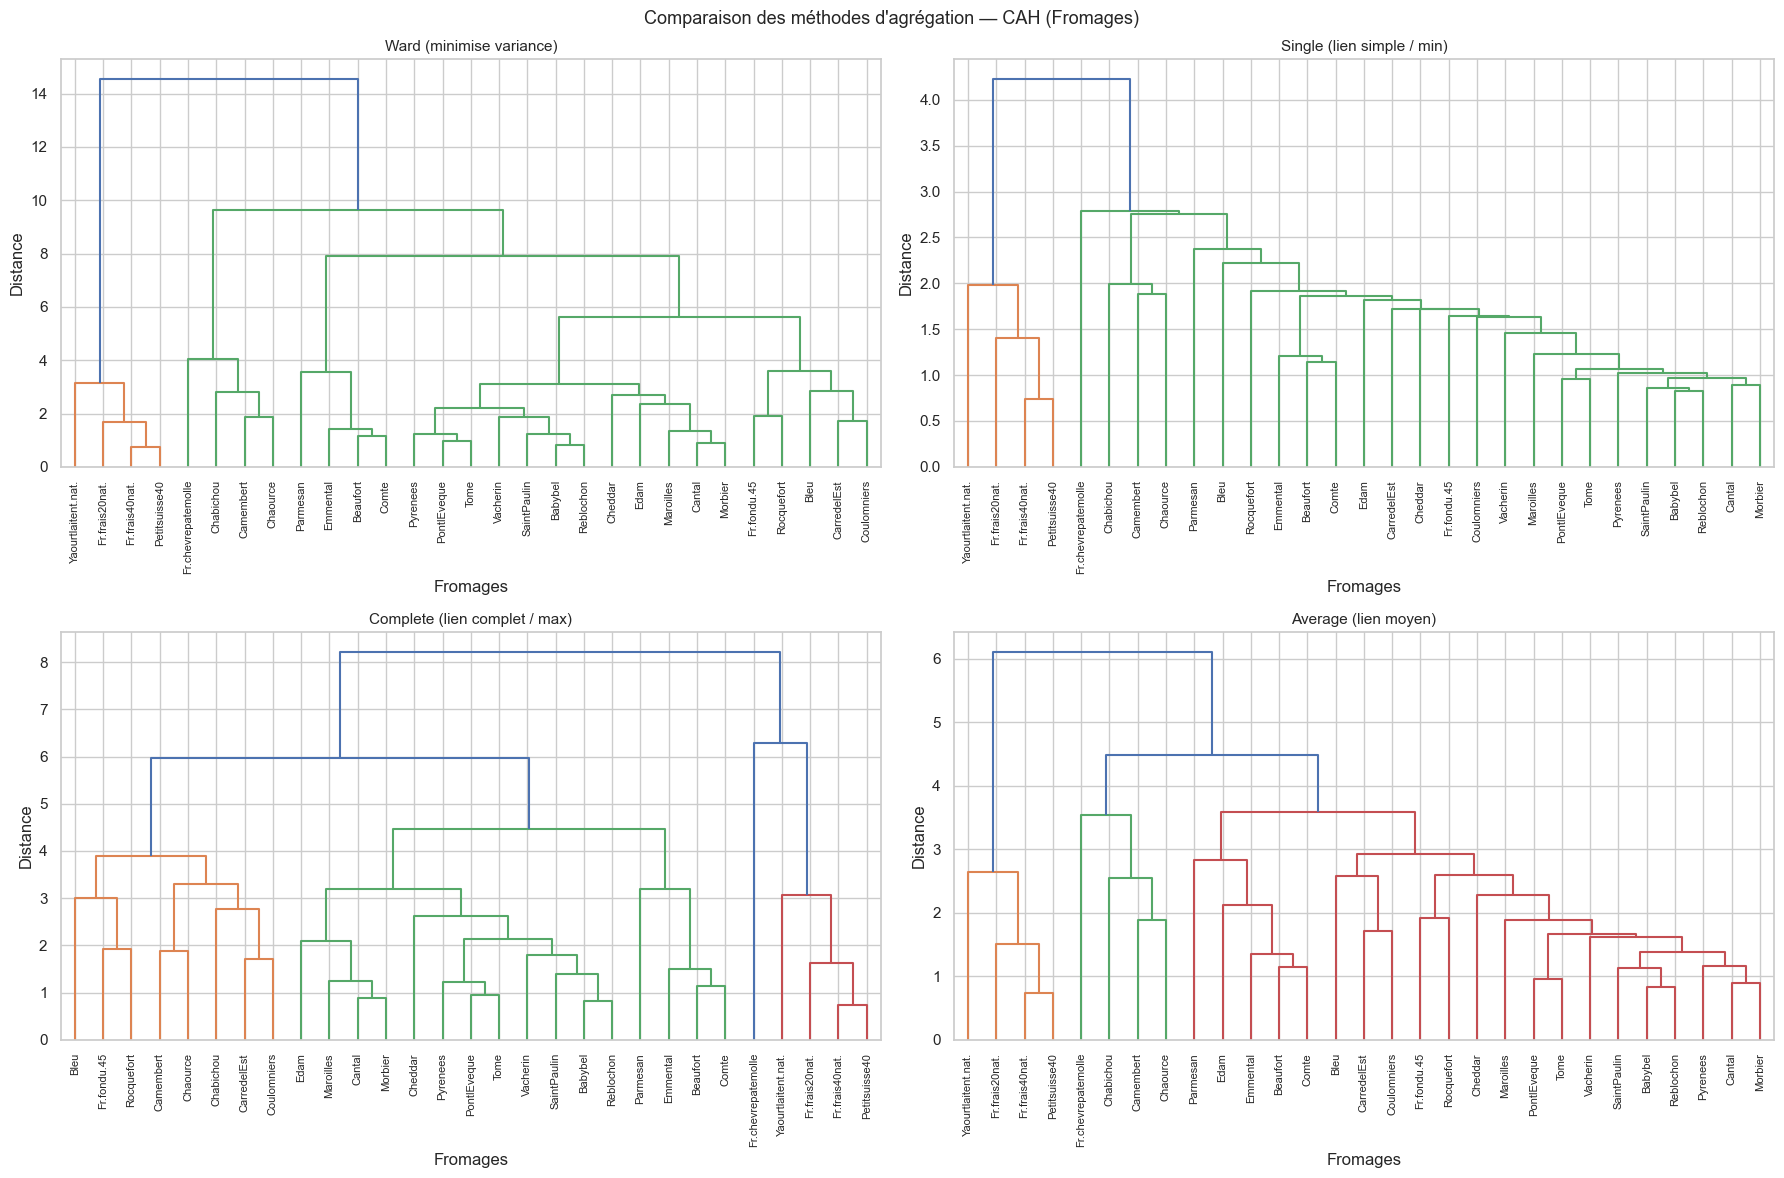

💡 Observations :
  - Ward : clusters équilibrés et compacts → recommandé pour la segmentation
  - Single : effet de chaîne (chain effect), un seul fromage atypique peut tout fusionner
  - Complete : clusters compacts mais plus sensibles aux outliers
  - Average : compromis entre single et complete


In [42]:
methodes = ['ward', 'single', 'complete', 'average']
titres   = ['Ward (minimise variance)', 'Single (lien simple / min)', 
            'Complete (lien complet / max)', 'Average (lien moyen)']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, method, titre in zip(axes, methodes, titres):
    cah = linkage(fromage_dist, method=method)
    dendrogram(
        cah, labels=fromage.index, ax=ax,
        leaf_rotation=90, leaf_font_size=8
    )
    ax.set_title(titre, fontsize=11)
    ax.set_xlabel('Fromages')
    ax.set_ylabel('Distance')

plt.suptitle('Comparaison des méthodes d\'agrégation — CAH (Fromages)', fontsize=13)
plt.tight_layout()
plt.show()

print('💡 Observations :')
print('  - Ward : clusters équilibrés et compacts → recommandé pour la segmentation')
print('  - Single : effet de chaîne (chain effect), un seul fromage atypique peut tout fusionner')
print('  - Complete : clusters compacts mais plus sensibles aux outliers')
print('  - Average : compromis entre single et complete')

### Q2 — Corrélation cophenétique (qualité de l'arbre)

In [43]:
# La corrélation cophenétique mesure l'accord entre les distances originales 
# et les distances dans l'arbre hiérarchique.
# Plus proche de 1 = l'arbre représente fidèlement la structure des données.

print('=== Corrélation cophenétique par méthode ===')
print('  (Plus proche de 1 = meilleure représentation)\n')

coph_results = {}
for method in methodes:
    cah = linkage(fromage_dist, method=method)
    c, coph_dists = cophenet(cah, fromage_dist)
    coph_results[method] = c
    print(f'  {method:10s} : r_cophenetic = {c:.4f}')

best_method = max(coph_results, key=coph_results.get)
print(f'\n✅ Meilleure méthode selon la corrélation cophenétique : {best_method} ({coph_results[best_method]:.4f})')

=== Corrélation cophenétique par méthode ===
  (Plus proche de 1 = meilleure représentation)

  ward       : r_cophenetic = 0.8598
  single     : r_cophenetic = 0.8415
  complete   : r_cophenetic = 0.8469
  average    : r_cophenetic = 0.8660

✅ Meilleure méthode selon la corrélation cophenétique : average (0.8660)


### Q3 — ACP + Clusters CAH sur le plan factoriel

=== Variance expliquée (fromages) ===
  PC1 : 56.1% (cumulé : 56.1%)
  PC2 : 20.5% (cumulé : 76.6%)
  PC3 : 9.6% (cumulé : 86.2%)
  PC4 : 6.4% (cumulé : 92.7%)
  PC5 : 3.9% (cumulé : 96.6%)
  PC6 : 1.9% (cumulé : 98.5%)
  PC7 : 1.1% (cumulé : 99.6%)
  PC8 : 0.3% (cumulé : 99.9%)
  PC9 : 0.1% (cumulé : 100.0%)


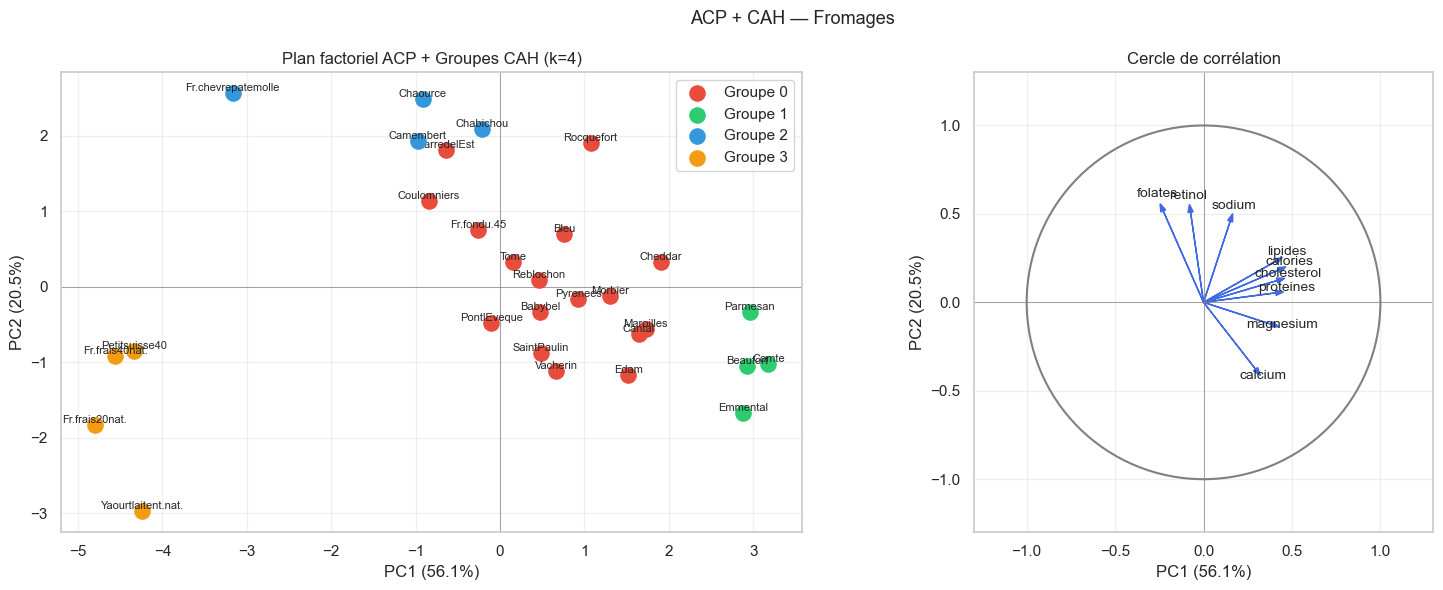

In [44]:
# ACP sur fromages standardisés
pca_fr = PCA()
coords_fr = pca_fr.fit_transform(fromage_cr)
var_exp_fr = pca_fr.explained_variance_ratio_

print('=== Variance expliquée (fromages) ===')
for i, v in enumerate(var_exp_fr):
    print(f'  PC{i+1} : {v*100:.1f}% (cumulé : {sum(var_exp_fr[:i+1])*100:.1f}%)')

# Projection avec couleurs des groupes CAH
couleurs_cah = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plan factoriel PC1-PC2
for g in range(4):
    mask = groupes_cah == g
    axes[0].scatter(
        coords_fr[mask, 0], coords_fr[mask, 1],
        c=couleurs_cah[g], s=120, label=f'Groupe {g}', zorder=3
    )
    for idx in np.where(mask)[0]:
        axes[0].annotate(
            fromage.index[idx], (coords_fr[idx, 0], coords_fr[idx, 1]),
            fontsize=8, ha='center', va='bottom'
        )

axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({var_exp_fr[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_exp_fr[1]*100:.1f}%)')
axes[0].set_title('Plan factoriel ACP + Groupes CAH (k=4)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cercle de corrélation
loadings_fr = pca_fr.components_.T
circle2 = plt.Circle((0, 0), 1, color='gray', fill=False, linewidth=1.5)
axes[1].add_patch(circle2)

for i, var in enumerate(fromage.drop(columns=['Groupe_CAH']).columns):
    axes[1].arrow(0, 0, loadings_fr[i, 0], loadings_fr[i, 1],
                  head_width=0.03, fc='royalblue', ec='royalblue')
    axes[1].text(loadings_fr[i, 0]*1.15, loadings_fr[i, 1]*1.15, var, fontsize=10, ha='center')

axes[1].set_xlim(-1.3, 1.3); axes[1].set_ylim(-1.3, 1.3)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({var_exp_fr[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_exp_fr[1]*100:.1f}%)')
axes[1].set_title('Cercle de corrélation')
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)

plt.suptitle('ACP + CAH — Fromages', fontsize=13)
plt.tight_layout()
plt.show()

### Q4 — Profils moyens pour les partitions en 2, 3, 4 et 5 groupes


=== Profils moyens — k=2 groupes ===
        calories  sodium  calcium  lipides  retinol  folates  proteines  \
Groupe                                                                    
0         331.76  236.54   194.05    27.02    69.55    12.46      22.24   
1         101.75   44.75   133.75     6.28    55.15    16.48       7.20   

        cholesterol  magnesium  
Groupe                          
0             83.60      29.48  
1             18.25      11.25  


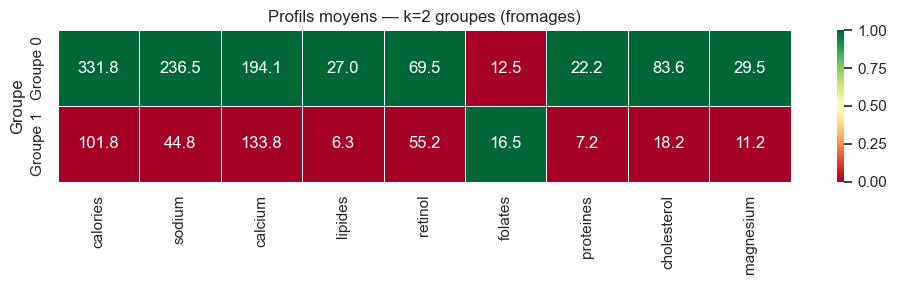


=== Profils moyens — k=3 groupes ===
        calories  sodium  calcium  lipides  retinol  folates  proteines  \
Groupe                                                                    
0         342.29  236.74   206.79    27.82    60.89     8.34      23.06   
1         276.50  235.50   127.20    22.82   115.00    34.05      17.95   
2         101.75   44.75   133.75     6.28    55.15    16.48       7.20   

        cholesterol  magnesium  
Groupe                          
0             87.14      30.48  
1             65.00      24.25  
2             18.25      11.25  


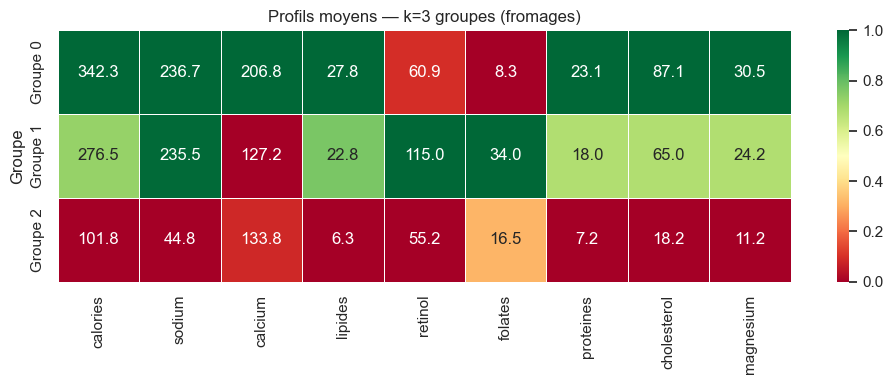


=== Profils moyens — k=4 groupes ===
        calories  sodium  calcium  lipides  retinol  folates  proteines  \
Groupe                                                                    
0         331.12  262.79   189.40    27.15    60.09     9.71      21.38   
1         389.75  126.00   280.68    30.65    64.28     2.52      30.22   
2         276.50  235.50   127.20    22.82   115.00    34.05      17.95   
3         101.75   44.75   133.75     6.28    55.15    16.48       7.20   

        cholesterol  magnesium  
Groupe                          
0             82.35      26.88  
1            107.50      45.75  
2             65.00      24.25  
3             18.25      11.25  


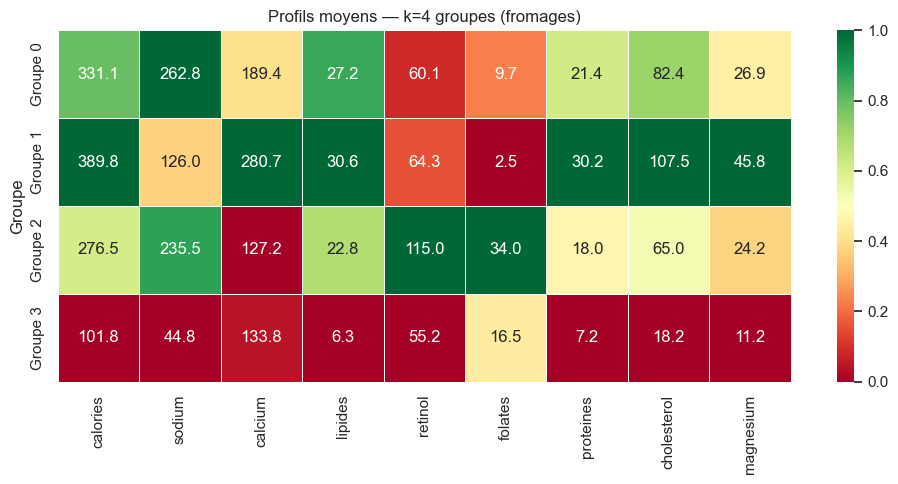


=== Profils moyens — k=5 groupes ===
        calories  sodium  calcium  lipides  retinol  folates  proteines  \
Groupe                                                                    
0         325.20  346.70   138.68    27.20    62.64    19.54      19.44   
1         333.58  227.83   210.53    27.13    59.03     5.62      22.18   
2         389.75  126.00   280.68    30.65    64.28     2.52      30.22   
3         276.50  235.50   127.20    22.82   115.00    34.05      17.95   
4         101.75   44.75   133.75     6.28    55.15    16.48       7.20   

        cholesterol  magnesium  
Groupe                          
0             82.00      21.00  
1             82.50      29.33  
2            107.50      45.75  
3             65.00      24.25  
4             18.25      11.25  


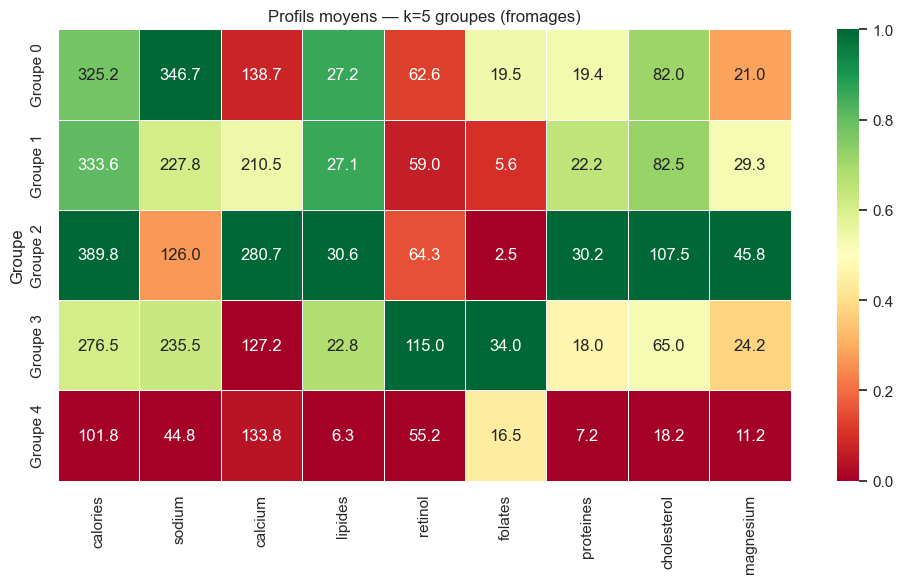

In [45]:
vars_fr = fromage.drop(columns=['Groupe_CAH']).columns.tolist()

for k in [2, 3, 4, 5]:
    g = cut_tree(cah_ward, n_clusters=k).flatten()
    df_temp = fromage[vars_fr].copy()
    df_temp['Groupe'] = g

    moyennes_k = df_temp.groupby('Groupe')[vars_fr].mean()

    print(f'\n=== Profils moyens — k={k} groupes ===')
    print(moyennes_k.round(2))

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, k+1))
    moy_norm = (moyennes_k - moyennes_k.min()) / (moyennes_k.max() - moyennes_k.min())
    sns.heatmap(
        moy_norm, annot=moyennes_k.round(1), fmt='.1f',
        cmap='RdYlGn', linewidths=0.5, ax=ax,
        yticklabels=[f'Groupe {i}' for i in range(k)]
    )
    ax.set_title(f'Profils moyens — k={k} groupes (fromages)')
    plt.tight_layout()
    plt.show()

### Q5 — Comparaison CAH vs K-means (k=4)

=== Matrice de contingence — CAH vs K-means (k=4) ===
K-means  0  1   2  3
CAH                 
0        2  1  14  0
1        0  4   0  0
2        4  0   0  0
3        0  0   0  4


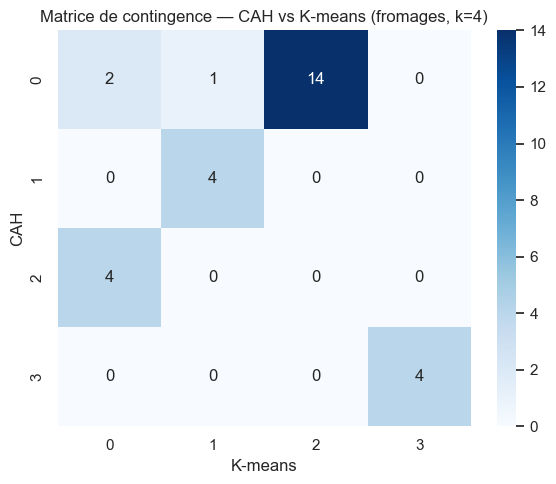


Fromages pour lesquels CAH et K-means divergent :
  • Babybel : CAH=0, K-means=2
  • Bleu : CAH=0, K-means=2
  • Camembert : CAH=2, K-means=0
  • Cantal : CAH=0, K-means=2
  • Chabichou : CAH=2, K-means=0
  • Chaource : CAH=2, K-means=0
  • Cheddar : CAH=0, K-means=2
  • Edam : CAH=0, K-means=1
  • Fr.chevrepatemolle : CAH=2, K-means=0
  • Fr.fondu.45 : CAH=0, K-means=2
  • Maroilles : CAH=0, K-means=2
  • Morbier : CAH=0, K-means=2
  • PontlEveque : CAH=0, K-means=2
  • Pyrenees : CAH=0, K-means=2
  • Reblochon : CAH=0, K-means=2
  • Rocquefort : CAH=0, K-means=2
  • SaintPaulin : CAH=0, K-means=2
  • Tome : CAH=0, K-means=2
  • Vacherin : CAH=0, K-means=2


In [46]:
# K-means sur fromages standardisés avec k=4
km_fr = KMeans(n_clusters=4, n_init=20, random_state=42)
labels_km_fr = km_fr.fit_predict(fromage_cr)

fromage['Groupe_Kmeans'] = labels_km_fr

# Matrice de contingence
contingence = pd.crosstab(
    fromage['Groupe_CAH'],
    fromage['Groupe_Kmeans'],
    rownames=['CAH'],
    colnames=['K-means']
)

print('=== Matrice de contingence — CAH vs K-means (k=4) ===')
print(contingence)

plt.figure(figsize=(6, 5))
sns.heatmap(contingence, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de contingence — CAH vs K-means (fromages, k=4)')
plt.tight_layout()
plt.show()

# Listing des différences
accord = (fromage['Groupe_CAH'].values == labels_km_fr)
print(f'\nFromages pour lesquels CAH et K-means divergent :')
for idx in fromage.index[~accord]:
    print(f'  • {idx} : CAH={fromage.loc[idx, "Groupe_CAH"]}, K-means={fromage.loc[idx, "Groupe_Kmeans"]}')

### Q6 — Silhouette pour estimer le k optimal

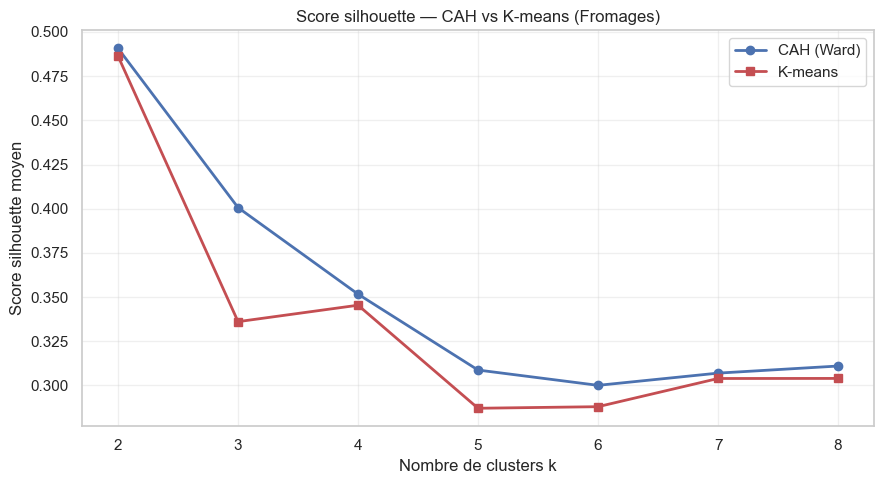

✅ k optimal CAH    (silhouette) = 2
✅ k optimal K-means (silhouette) = 2


In [47]:
# Silhouette pour la CAH (partitions de k=2 à 8)
silh_cah  = []
silh_kmeans = []
ks = range(2, 9)

for k in ks:
    # CAH
    g_cah = cut_tree(cah_ward, n_clusters=k).flatten()
    silh_cah.append(silhouette_score(fromage_cr, g_cah))

    # K-means
    km_k = KMeans(n_clusters=k, n_init=20, random_state=42).fit(fromage_cr)
    silh_kmeans.append(silhouette_score(fromage_cr, km_k.labels_))

plt.figure(figsize=(9, 5))
plt.plot(ks, silh_cah,    'bo-', linewidth=2, label='CAH (Ward)')
plt.plot(ks, silh_kmeans, 'rs-', linewidth=2, label='K-means')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Score silhouette moyen')
plt.title('Score silhouette — CAH vs K-means (Fromages)')
plt.legend()
plt.xticks(list(ks))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_cah    = list(ks)[np.argmax(silh_cah)]
best_k_kmeans = list(ks)[np.argmax(silh_kmeans)]
print(f'✅ k optimal CAH    (silhouette) = {best_k_cah}')
print(f'✅ k optimal K-means (silhouette) = {best_k_kmeans}')

### Q7 — Suppression d'un fromage atypique et impact sur la CAH

Fromage le plus atypique (z-score max = 3.49) : Fr.chevrepatemolle
Ses valeurs : {'calories': 206.0, 'sodium': 160.0, 'calcium': 72.8, 'lipides': 18.5, 'retinol': 150.5, 'folates': 31.0, 'proteines': 11.1, 'cholesterol': 50.0, 'magnesium': 16.0}


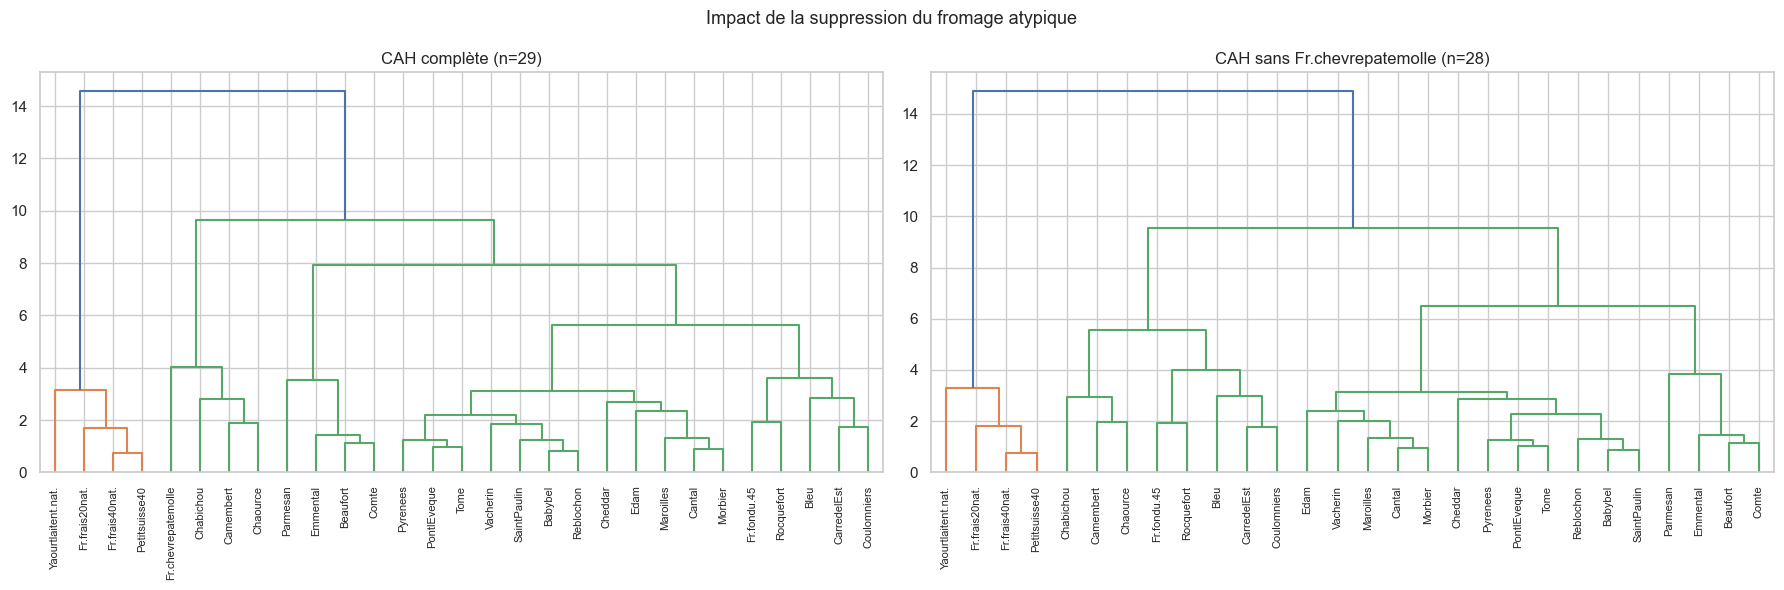


Top 5 sauts d'inertie AVEC le fromage atypique :
  Rang 0 : 14.5581
  Rang 1 : 9.6478
  Rang 2 : 7.9208
  Rang 3 : 5.6177
  Rang 4 : 4.0452

Top 5 sauts d'inertie SANS le fromage atypique :
  Rang 0 : 14.8735
  Rang 1 : 9.5524
  Rang 2 : 6.5089
  Rang 3 : 5.5620
  Rang 4 : 3.9850


In [48]:
# Identifier les fromages atypiques via z-score
from scipy import stats

z_scores = np.abs(stats.zscore(fromage[vars_fr]))
z_max_par_fromage = z_scores.max(axis=1)
fromage_outlier = fromage.index[np.argmax(z_max_par_fromage)]

print(f'Fromage le plus atypique (z-score max = {z_max_par_fromage.max():.2f}) : {fromage_outlier}')
print(f'Ses valeurs : {fromage.loc[fromage_outlier, vars_fr].to_dict()}')

# CAH sans le fromage atypique
fromage_sans = fromage[vars_fr].drop(index=fromage_outlier)
fromage_sans_cr = StandardScaler().fit_transform(fromage_sans)
dist_sans = pdist(fromage_sans_cr, metric='euclidean')
cah_sans  = linkage(dist_sans, method='ward')

# Comparaison des dendrogrammes
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dendrogram(cah_ward, labels=fromage[vars_fr].index, ax=axes[0],
           leaf_rotation=90, leaf_font_size=8)
axes[0].set_title(f'CAH complète (n={len(fromage)})')

dendrogram(cah_sans, labels=fromage_sans.index, ax=axes[1],
           leaf_rotation=90, leaf_font_size=8)
axes[1].set_title(f'CAH sans {fromage_outlier} (n={len(fromage_sans)})')

plt.suptitle('Impact de la suppression du fromage atypique', fontsize=13)
plt.tight_layout()
plt.show()

# Comparaison des sauts d'inertie
inertie_sans = np.sort(cah_sans[:, 2])[::-1]
print('\nTop 5 sauts d\'inertie AVEC le fromage atypique :')
for i, v in enumerate(np.sort(cah_ward[:, 2])[::-1][:5]):
    print(f'  Rang {i} : {v:.4f}')
print('\nTop 5 sauts d\'inertie SANS le fromage atypique :')
for i, v in enumerate(inertie_sans[:5]):
    print(f'  Rang {i} : {v:.4f}')

---
## 🏁 Récapitulatif final

| Méthode | Dataset | k optimal | Observation principale |
|---|---|---|---|
| K-means | cars.xls | 3 | Sépare voitures légères/économiques, intermédiaires, grosses/puissantes |
| PAM (Gower) | cars.xls | 3 | Résultats similaires au K-means, gère mieux les variables mixtes |
| CAH Ward | fromage.txt | 4 | Structure hiérarchique claire, groupes nutritionnels distincts |
| K-means | fromage.txt | 4 | Accord partiel avec la CAH, quelques divergences |

### Conseils pratiques
- **Toujours standardiser** avant K-means ou CAH (sauf si les variables sont déjà comparables)
- **Combiner plusieurs indices** (coude + silhouette + Calinski-Harabasz) pour choisir k
- **Utiliser l'ACP** pour visualiser et valider les clusters
- **Comparer CAH et K-means** : la CAH donne une vision hiérarchique, K-means optimise l'inertie